<a href="https://colab.research.google.com/github/TrishaGanesha/CVProject/blob/main/CVProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Fundamentals: A Manual Implementation Journey

## 01. Introduction to Computer Vision & Image Processing

**Computer Vision (CV)** is a field of artificial intelligence that enables computers to 'see' and interpret visual data from the real world. It involves processing, analyzing, and understanding digital images and videos to automate tasks that the human visual system can perform.

**Image Processing (IP)**, on the other hand, is a subfield that focuses on performing operations on an image to enhance it or extract some useful information from it. The input is an image, and the output is also an image or characteristics/features associated with that image.

### Image Processing vs Computer Vision

While closely related and often overlapping, the distinction lies in their goals:

*   **Image Processing**: Deals with **how** to manipulate images. It's about changing pixel values, enhancing clarity, or extracting low-level features. The goal is often to improve the image for human interpretation or to prepare it for further machine analysis.
    *   *Example*: Adjusting brightness and contrast, removing noise, sharpening edges.

*   **Computer Vision**: Deals with **what** the image represents. It aims to enable machines to understand and make decisions based on the visual content. It often builds upon the outputs of image processing to perform higher-level tasks.
    *   *Example*: Recognizing objects in a scene, detecting faces, tracking movement, autonomous navigation.

In essence, Image Processing is often a foundational step for Computer Vision tasks, but CV goes further to interpret the meaning of the visual data.

## Problem Statement: Defective Product Detection on an Assembly Line

Imagine an automated assembly line where various products are being manufactured. Due to mechanical issues or material inconsistencies, some products may emerge with defects, such as incorrect shapes, missing components, or surface imperfections. Manually inspecting every product is time-consuming, prone to human error, and expensive.

**Goal**: Develop a simplified computer vision system capable of identifying specific types of defects on products as they pass through the assembly line, using basic image processing and computer vision techniques implemented from scratch.

For this exercise, we will focus on a subset of the problem: **detecting anomalies or specific features** within images that might indicate a defect. We'll start by understanding image characteristics and building up to feature extraction, without relying on advanced pre-built libraries for core algorithms.

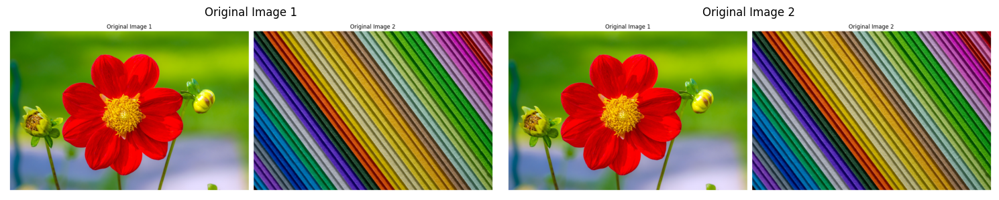

In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load the images for demonstration
# We'll use Pillow (PIL) for basic image loading,
# but all subsequent processing will be implemented manually with numpy.
image_paths = [
    '/content/flower.png',
    '/content/rainbow.png'
]

# Load and convert to RGB (if necessary) then to numpy array
def load_image_as_numpy(path):
    try:
        img = Image.open(path).convert('RGB')
        return np.array(img)
    except FileNotFoundError:
        print(f"Error: Image not found at {path}")
        return None

original_images = [load_image_as_numpy(p) for p in image_paths if load_image_as_numpy(p) is not None]

if not original_images:
    print("No images loaded. Please ensure the files are uploaded to /content/ and re-run this cell.")

# Display original images
if original_images:
    fig, axes = plt.subplots(1, len(original_images), figsize=(15, 7))
    if len(original_images) == 1:
        axes = [axes] # Make it iterable for consistency

    for i, img_np in enumerate(original_images):
        axes[i].imshow(img_np)
        axes[i].set_title(f'Original Image {i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## 04. Types of Images: Binary, Grayscale, Color Images

Images can be represented in different formats, each suitable for various tasks. Understanding these types is fundamental.

*   **Color Images**: These images typically use three channels (Red, Green, Blue - RGB) to represent a full spectrum of colors. Each pixel has three intensity values.
*   **Grayscale Images**: These images represent shades of gray, ranging from black to white. Each pixel has a single intensity value, usually from 0 (black) to 255 (white).
*   **Binary Images**: These are the simplest form, containing only two colors, typically black and white. Each pixel has one of two possible values (e.g., 0 or 1, representing black or white). They are often used for segmentation or morphological operations.

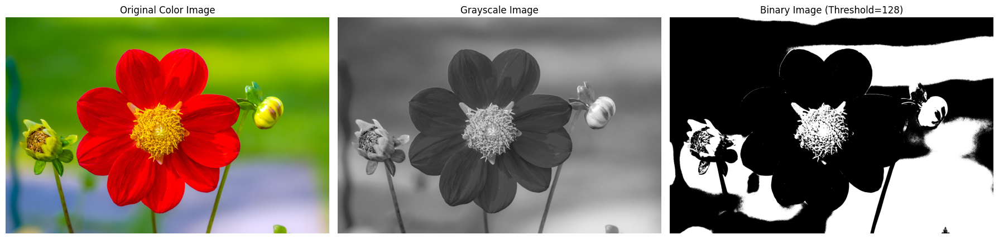

In [ ]:
# Convert a color image to grayscale (manual implementation)
def convert_to_grayscale(image_rgb):
    # A common method to convert RGB to grayscale is using a weighted average:
    # Grayscale = 0.2989 * R + 0.5870 * G + 0.1140 * B
    # Ensure the input is a 3-channel image
    if image_rgb.ndim != 3 or image_rgb.shape[2] != 3:
        return image_rgb # Already grayscale or invalid format

    # Manual calculation for each channel
    r_channel = image_rgb[:, :, 0]
    g_channel = image_rgb[:, :, 1]
    b_channel = image_rgb[:, :, 2]

    grayscale_image = (0.2989 * r_channel +
                       0.5870 * g_channel +
                       0.1140 * b_channel)

    # Convert to unsigned 8-bit integer type (0-255 range)
    return grayscale_image.astype(np.uint8)

# Convert a grayscale image to binary (manual implementation)
def convert_to_binary(image_grayscale, threshold_value):
    # Ensure the input is a single-channel image (grayscale)
    if image_grayscale.ndim != 2:
        return image_grayscale # Already binary or invalid format

    # Manual thresholding: pixels > threshold become 255 (white), others 0 (black)
    binary_image = np.zeros_like(image_grayscale, dtype=np.uint8)
    rows, cols = image_grayscale.shape
    for r in range(rows):
        for c in range(cols):
            if image_grayscale[r, c] > threshold_value:
                binary_image[r, c] = 255
            else:
                binary_image[r, c] = 0
    return binary_image

# Use the first loaded image for demonstration
if original_images:
    demo_image = original_images[0]

    # Convert to grayscale
    gray_image = convert_to_grayscale(demo_image)

    # Convert to binary (choose a threshold, e.g., 128)
    binary_image = convert_to_binary(gray_image, 128)

    # Display the results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(demo_image)
    axes[0].set_title('Original Color Image')
    axes[0].axis('off')

    axes[1].imshow(gray_image, cmap='gray')
    axes[1].set_title('Grayscale Image')
    axes[1].axis('off')

    axes[2].imshow(binary_image, cmap='gray')
    axes[2].set_title('Binary Image (Threshold=128)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## 05. Image Channels: Splitting, Merging, Manipulating Color Pixels

Color images are typically composed of multiple channels, most commonly Red, Green, and Blue (RGB). Understanding how to split, merge, and manipulate these individual channels is crucial for many image processing tasks, such as color correction, specific feature enhancement, or color-based segmentation.

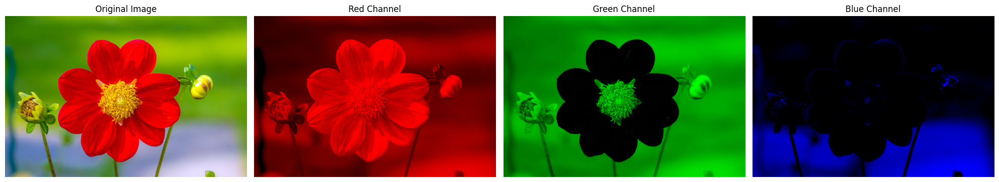

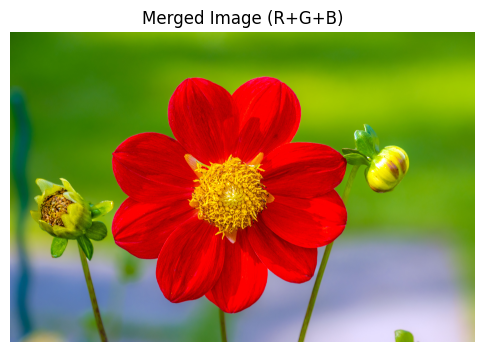

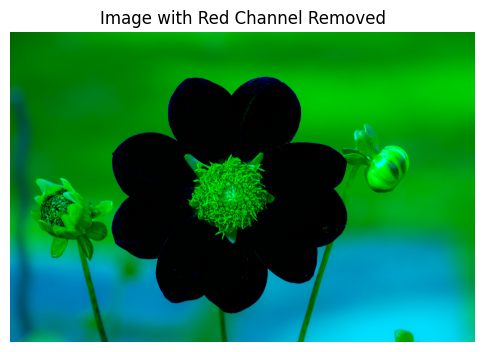

In [ ]:
# Split RGB channels (manual implementation)
def split_channels(image_rgb):
    # Ensure the input is a 3-channel image
    if image_rgb.ndim != 3 or image_rgb.shape[2] != 3:
        print("Error: Input must be a 3-channel RGB image for splitting.")
        return None, None, None

    r_channel = image_rgb[:, :, 0]
    g_channel = image_rgb[:, :, 1]
    b_channel = image_rgb[:, :, 2]
    return r_channel, g_channel, b_channel

# Merge RGB channels (manual implementation)
def merge_channels(r, g, b):
    # Ensure all channels have the same shape
    if not (r.shape == g.shape == b.shape):
        print("Error: All channels must have the same dimensions for merging.")
        return None

    # Create an empty array for the merged image
    merged_image = np.zeros((*r.shape, 3), dtype=np.uint8)
    merged_image[:, :, 0] = r
    merged_image[:, :, 1] = g
    merged_image[:, :, 2] = b
    return merged_image

# Manipulate a specific color channel (e.g., set red channel to zero)
def manipulate_channel(image_rgb, channel_index, value=0):
    manipulated_image = np.copy(image_rgb)
    # Ensure the channel index is valid (0 for R, 1 for G, 2 for B)
    if 0 <= channel_index < manipulated_image.shape[2]:
        manipulated_image[:, :, channel_index] = value
    else:
        print(f"Warning: Invalid channel index {channel_index}. Image not modified.")
    return manipulated_image

# Use the first loaded image for demonstration
if original_images:
    demo_image = original_images[0]

    # Split channels
    red, green, blue = split_channels(demo_image)

    # Display individual channels (as grayscale)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(demo_image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # For displaying single channels as red/green/blue, create a zero array for other channels
    red_only = np.zeros_like(demo_image)
    red_only[:, :, 0] = red
    axes[1].imshow(red_only)
    axes[1].set_title('Red Channel')
    axes[1].axis('off')

    green_only = np.zeros_like(demo_image)
    green_only[:, :, 1] = green
    axes[2].imshow(green_only)
    axes[2].set_title('Green Channel')
    axes[2].axis('off')

    blue_only = np.zeros_like(demo_image)
    blue_only[:, :, 2] = blue
    axes[3].imshow(blue_only)
    axes[3].set_title('Blue Channel')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    # Example of merging channels back (should look like original)
    merged_image = merge_channels(red, green, blue)
    plt.figure(figsize=(6, 6))
    plt.imshow(merged_image)
    plt.title('Merged Image (R+G+B)')
    plt.axis('off')
    plt.show()

    # Example of manipulating a channel: remove all red
    no_red_image = manipulate_channel(demo_image, 0, value=0) # Channel 0 is Red
    plt.figure(figsize=(6, 6))
    plt.imshow(no_red_image)
    plt.title('Image with Red Channel Removed')
    plt.axis('off')
    plt.show()

## 06. Mathematical Operations on Images: Linear and Non-Linear Operations

Image manipulation often involves applying mathematical operations to pixel values. These operations can be categorized as linear or non-linear, impacting how pixel intensities are transformed.

### Linear Operations

Linear operations involve transforming pixel values using linear functions, such as addition, subtraction, multiplication, or division by a constant. These operations affect all pixels uniformly and preserve relative differences in intensity.

*   **Brightness Adjustment (Addition/Subtraction)**: Adding or subtracting a constant value to all pixel intensities.
*   **Contrast Adjustment (Multiplication/Division)**: Multiplying or dividing all pixel intensities by a constant value.

### Non-Linear Operations

Non-linear operations apply non-linear functions to pixel values, meaning the output is not a linear combination of the input. These can be useful for more complex transformations, such as enhancing specific ranges of intensity or applying thresholding.

*   **Power-Law (Gamma) Transformation**: Used for correcting display gamma or for general contrast enhancement/reduction.
*   **Logarithmic Transformation**: Used to expand the intensity values of dark pixels while compressing the intensity values of bright pixels, often useful for images with a large dynamic range.

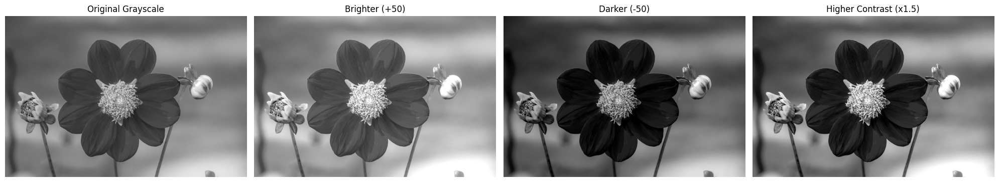

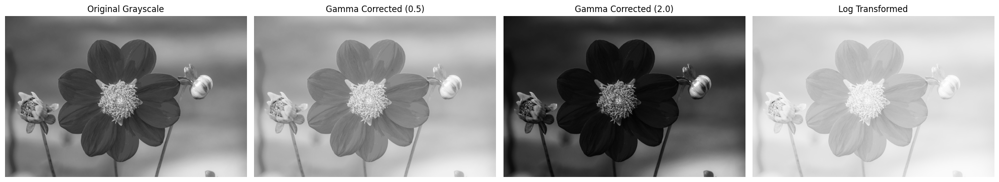

In [ ]:
# Implement manual linear and non-linear operations

# Linear: Brightness Adjustment (manual)
def adjust_brightness(image, value):
    # Ensure result stays within 0-255 range
    return np.clip(image.astype(np.int32) + value, 0, 255).astype(np.uint8)

# Linear: Contrast Adjustment (manual)
def adjust_contrast(image, factor):
    # For contrast, often multiply around a midpoint (e.g., 128)
    # (pixel - midpoint) * factor + midpoint
    midpoint = 128
    contrasted_image = (image.astype(np.float32) - midpoint) * factor + midpoint
    return np.clip(contrasted_image, 0, 255).astype(np.uint8)

# Non-Linear: Gamma Correction (manual)
def gamma_correction(image, gamma):
    # Normalize image to 0-1 range, apply gamma, then scale back to 0-255
    normalized_image = image.astype(np.float32) / 255.0
    gamma_corrected_image = np.power(normalized_image, gamma) * 255.0
    return np.clip(gamma_corrected_image, 0, 255).astype(np.uint8)

# Non-Linear: Logarithmic Transformation (manual)
def log_transform(image, c=1):
    # Log transform: output = c * log(1 + input_pixel_value)
    # Normalize image to 0-1 range for log, then scale back
    normalized_image = image.astype(np.float32) + 1 # Add 1 to avoid log(0)
    log_transformed_image = c * np.log(normalized_image)
    # Scale back to 0-255 range, assuming max value of log(256) is roughly 5.5
    log_transformed_image = log_transformed_image * (255.0 / np.max(log_transformed_image))
    return np.clip(log_transformed_image, 0, 255).astype(np.uint8)


# Use the grayscale image for these demonstrations for simplicity
if 'gray_image' in locals() and gray_image is not None:
    # Linear Operations
    bright_image = adjust_brightness(gray_image, 50) # Increase brightness by 50
    dark_image = adjust_brightness(gray_image, -50) # Decrease brightness by 50
    high_contrast_image = adjust_contrast(gray_image, 1.5) # Increase contrast by 50%

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale')
    axes[0].axis('off')
    axes[1].imshow(bright_image, cmap='gray')
    axes[1].set_title('Brighter (+50)')
    axes[1].axis('off')
    axes[2].imshow(dark_image, cmap='gray')
    axes[2].set_title('Darker (-50)')
    axes[2].axis('off')
    axes[3].imshow(high_contrast_image, cmap='gray')
    axes[3].set_title('Higher Contrast (x1.5)')
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()

    # Non-Linear Operations
    gamma_low = gamma_correction(gray_image, 0.5) # Gamma < 1 makes dark regions brighter
    gamma_high = gamma_correction(gray_image, 2.0) # Gamma > 1 makes dark regions darker
    log_transformed = log_transform(gray_image)

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale')
    axes[0].axis('off')
    axes[1].imshow(gamma_low, cmap='gray')
    axes[1].set_title('Gamma Corrected (0.5)')
    axes[1].axis('off')
    axes[2].imshow(gamma_high, cmap='gray')
    axes[2].set_title('Gamma Corrected (2.0)')
    axes[2].axis('off')
    axes[3].imshow(log_transformed, cmap='gray')
    axes[3].set_title('Log Transformed')
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Grayscale image not available for mathematical operations demonstration.")

## 07. Mathematical Operations on Images: Arithmetic and Logical Operations

Beyond basic intensity adjustments, images can be combined or manipulated using arithmetic and logical operations, typically applied pixel-wise. These are fundamental for tasks like image blending, masking, or detecting differences between images.

### Arithmetic Operations

These involve basic mathematical operations between two images (or an image and a scalar):

*   **Addition**: `Image1 + Image2` (e.g., blending, averaging multiple images).
*   **Subtraction**: `Image1 - Image2` (e.g., detecting changes, background subtraction).
*   **Multiplication**: `Image1 * Image2` (e.g., masking, intensity scaling).
*   **Division**: `Image1 / Image2`.

### Logical Operations

These operations are typically performed on binary images or on images treated as binary (e.g., after thresholding), pixel by pixel. They are based on Boolean logic (`AND`, `OR`, `NOT`, `XOR`).

*   **AND**: `Image1 AND Image2` (pixels are white only if both images are white at that position).
*   **OR**: `Image1 OR Image2` (pixels are white if at least one image is white).
*   **NOT**: `NOT Image1` (inverts the image: white becomes black, black becomes white).
*   **XOR**: `Image1 XOR Image2` (pixels are white if they are different in the two images).

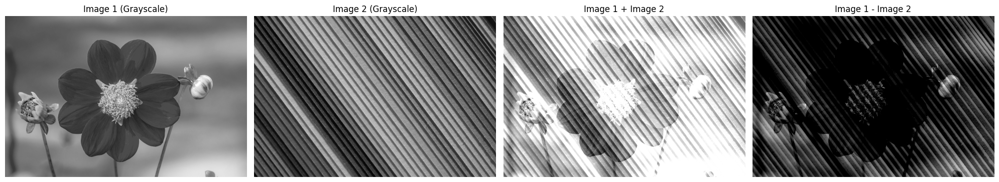

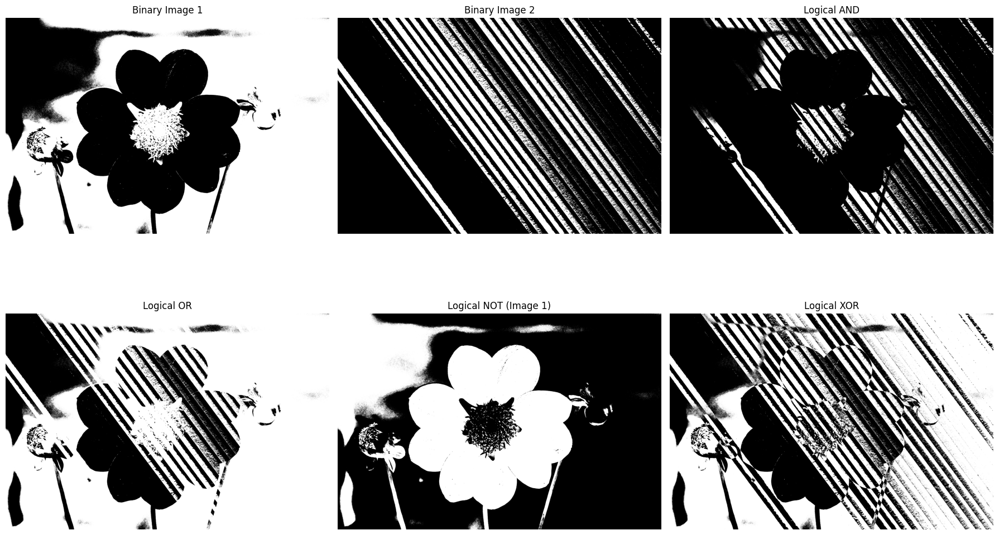

In [ ]:
# Implement manual arithmetic and logical operations

# Arithmetic Operations (manual)
def add_images(img1, img2):
    # Ensure images have the same shape for pixel-wise operations
    if img1.shape != img2.shape:
        print("Error: Images must have the same dimensions for addition.")
        return None
    return np.clip(img1.astype(np.int32) + img2.astype(np.int32), 0, 255).astype(np.uint8)

def subtract_images(img1, img2):
    if img1.shape != img2.shape:
        print("Error: Images must have the same dimensions for subtraction.")
        return None
    return np.clip(img1.astype(np.int32) - img2.astype(np.int32), 0, 255).astype(np.uint8)

# Logical Operations (manual - typically on binary images)
def logical_and(img1_binary, img2_binary):
    if img1_binary.shape != img2_binary.shape:
        print("Error: Images must have the same dimensions for logical AND.")
        return None
    # Pixels are 255 if both are 255, else 0
    return np.where((img1_binary == 255) & (img2_binary == 255), 255, 0).astype(np.uint8)

def logical_or(img1_binary, img2_binary):
    if img1_binary.shape != img2_binary.shape:
        print("Error: Images must have the same dimensions for logical OR.")
        return None
    # Pixels are 255 if either is 255, else 0
    return np.where((img1_binary == 255) | (img2_binary == 255), 255, 0).astype(np.uint8)

def logical_not(img_binary):
    # Invert binary image: 255 becomes 0, 0 becomes 255
    return np.where(img_binary == 255, 0, 255).astype(np.uint8)

def logical_xor(img1_binary, img2_binary):
    if img1_binary.shape != img2_binary.shape:
        print("Error: Images must have the same dimensions for logical XOR.")
        return None
    # Pixels are 255 if they are different, else 0
    return np.where((img1_binary == 255) != (img2_binary == 255), 255, 0).astype(np.uint8)


# Use two loaded images for arithmetic operations (convert them to grayscale first)
if len(original_images) >= 2:
    img1_color = original_images[0]
    img2_color = original_images[1]

    img1_gray = convert_to_grayscale(img1_color)
    img2_gray = convert_to_grayscale(img2_color)

    # Resize second image to match the first if necessary (for simplicity in demo)
    if img1_gray.shape != img2_gray.shape:
        # Simple resizing with PIL for demonstration, though manual resize could be implemented
        img2_pil = Image.fromarray(original_images[1])
        img2_resized_pil = img2_pil.resize((img1_color.shape[1], img1_color.shape[0]))
        img2_resized_np = np.array(img2_resized_pil)
        img2_gray = convert_to_grayscale(img2_resized_np)

    added_image = add_images(img1_gray, img2_gray)
    subtracted_image = subtract_images(img1_gray, img2_gray)

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(img1_gray, cmap='gray')
    axes[0].set_title('Image 1 (Grayscale)')
    axes[0].axis('off')
    axes[1].imshow(img2_gray, cmap='gray')
    axes[1].set_title('Image 2 (Grayscale)')
    axes[1].axis('off')
    axes[2].imshow(added_image, cmap='gray')
    axes[2].set_title('Image 1 + Image 2')
    axes[2].axis('off')
    axes[3].imshow(subtracted_image, cmap='gray')
    axes[3].set_title('Image 1 - Image 2')
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()

    # Logical Operations (using binary versions of the images)
    # First, create binary versions of the grayscale images
    binary_img1 = convert_to_binary(img1_gray, 100) # Using different thresholds to show variety
    binary_img2 = convert_to_binary(img2_gray, 150)

    and_result = logical_and(binary_img1, binary_img2)
    or_result = logical_or(binary_img1, binary_img2)
    not_result_1 = logical_not(binary_img1)
    xor_result = logical_xor(binary_img1, binary_img2)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes[0, 0].imshow(binary_img1, cmap='gray')
    axes[0, 0].set_title('Binary Image 1')
    axes[0, 0].axis('off')
    axes[0, 1].imshow(binary_img2, cmap='gray')
    axes[0, 1].set_title('Binary Image 2')
    axes[0, 1].axis('off')
    axes[0, 2].imshow(and_result, cmap='gray')
    axes[0, 2].set_title('Logical AND')
    axes[0, 2].axis('off')
    axes[1, 0].imshow(or_result, cmap='gray')
    axes[1, 0].set_title('Logical OR')
    axes[1, 0].axis('off')
    axes[1, 1].imshow(not_result_1, cmap='gray')
    axes[1, 1].set_title('Logical NOT (Image 1)')
    axes[1, 1].axis('off')
    axes[1, 2].imshow(xor_result, cmap='gray')
    axes[1, 2].set_title('Logical XOR')
    axes[1, 2].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Two images are needed for arithmetic and logical operations demonstration.")

## 08. Binary Image Processing: Thresholding

Thresholding is a simple yet powerful technique in image processing used to convert a grayscale image into a binary image. It works by setting a threshold value. Pixels with intensity values above the threshold are assigned one value (e.g., white or 255), and pixels below or equal to the threshold are assigned another (e.g., black or 0).

### Types of Thresholding:

*   **Simple/Global Thresholding**: A single threshold value is applied to the entire image. This is effective when there's a clear distinction between the foreground and background intensities.
*   **Adaptive Thresholding**: The threshold value varies across the image. This is useful for images with varying lighting conditions, where a single global threshold would not work well.

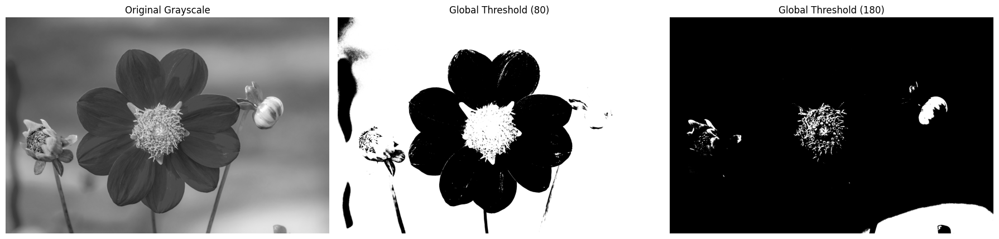

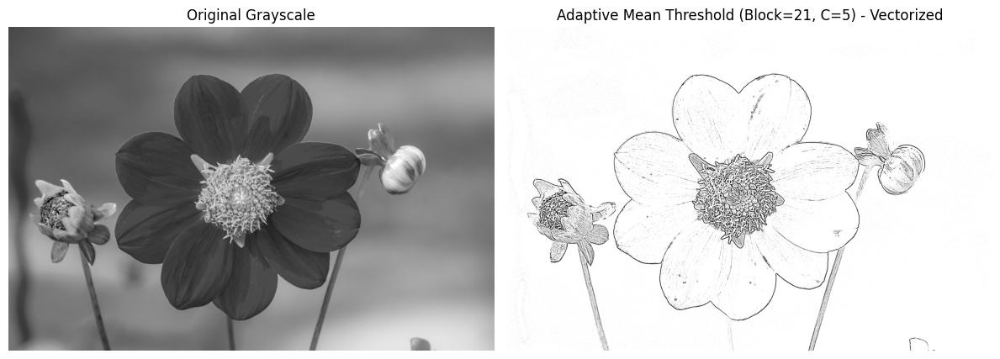

In [ ]:
# Manual implementation of Global Thresholding (vectorized)
def global_thresholding(image_grayscale, threshold_value):
    if image_grayscale.ndim != 2:
        print("Error: Input must be a grayscale image for global thresholding.")
        return image_grayscale

    # Vectorized comparison and assignment
    binary_image = (image_grayscale > threshold_value).astype(np.uint8) * 255
    return binary_image

# Optimized Adaptive Mean Thresholding using Integral Image (Pure NumPy, vectorized)
def adaptive_mean_thresholding(image_grayscale, block_size, C):
    if image_grayscale.ndim != 2:
        print("Error: Input must be a grayscale image for adaptive thresholding.")
        return image_grayscale.astype(np.uint8)

    rows, cols = image_grayscale.shape

    # 1. Compute integral image (Summed Area Table)
    # Pad with one extra row/column of zeros to simplify calculations for region sums
    integral_image = np.zeros((rows + 1, cols + 1), dtype=np.int32)
    # Vectorized cumulative sum
    integral_image[1:, 1:] = image_grayscale.cumsum(axis=0).cumsum(axis=1)

    half_block = block_size // 2

    # Create arrays of r_min, r_max, c_min, c_max for every pixel (r, c) in the image
    # These will be 2D arrays of shape (rows, cols) after broadcasting
    r_indices = np.arange(rows)
    c_indices = np.arange(cols)

    R_min = np.maximum(0, r_indices[:, None] - half_block)
    R_max = np.minimum(rows - 1, r_indices[:, None] + half_block)
    C_min = np.maximum(0, c_indices - half_block)
    C_max = np.minimum(cols - 1, c_indices + half_block)

    # Calculate actual window sizes (for correct averaging)
    Actual_block_rows = R_max - R_min + 1
    Actual_block_cols = C_max - C_min + 1
    Area = Actual_block_rows * Actual_block_cols

    # Calculate local sum using integral image (vectorized version of the sum formula)
    # Adjust for integral image indexing (+1)
    Sum_neighborhood = (
        integral_image[R_max + 1, C_max + 1] -
        integral_image[R_min, C_max + 1] -
        integral_image[R_max + 1, C_min] +
        integral_image[R_min, C_min]
    )

    # Calculate local mean
    # Use np.divide with 'where' to avoid division by zero and return 0 for those cases
    local_mean = np.divide(Sum_neighborhood, Area, out=np.zeros_like(Sum_neighborhood, dtype=np.float32), where=Area!=0)

    # Calculate threshold for each pixel
    threshold = local_mean - C

    # Apply thresholding
    adaptive_binary_image = (image_grayscale > threshold).astype(np.uint8) * 255

    return adaptive_binary_image


# Use the first loaded grayscale image for demonstration
if 'gray_image' in locals() and gray_image is not None:
    # Global Thresholding
    global_thresh_image_low = global_thresholding(gray_image, 80)
    global_thresh_image_high = global_thresholding(gray_image, 180)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale')
    axes[0].axis('off')
    axes[1].imshow(global_thresh_image_low, cmap='gray')
    axes[1].set_title('Global Threshold (80)')
    axes[1].axis('off')
    axes[2].imshow(global_thresh_image_high, cmap='gray')
    axes[2].set_title('Global Threshold (180)')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    # Adaptive Thresholding (now vectorized)
    # For demo, use a block size that makes sense visually
    adaptive_thresh_image = adaptive_mean_thresholding(gray_image, block_size=21, C=5)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale')
    axes[0].axis('off')
    axes[1].imshow(adaptive_thresh_image, cmap='gray')
    axes[1].set_title('Adaptive Mean Threshold (Block=21, C=5) - Vectorized')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Grayscale image not available for thresholding demonstration.")

## 09. Morphological Operations: Erosion and Dilation

Morphological operations are a set of non-linear operations related to the shape or morphology of features in an image. They are typically applied to binary images but can also be extended to grayscale images. These operations fundamentally rely on a **structuring element** (or kernel) which is a small matrix or shape used to probe the image.

### Erosion

**Erosion** 'shrinks' or 'thins' objects in a binary image. A pixel in the output image is set to 1 (white) only if *all* pixels under the structuring element in the input image are 1. Otherwise, it's set to 0 (black). This has the effect of removing small isolated 'noise' pixels, detaching objects that are connected by small bridges, and making objects smaller.

**Problem Statement for Erosion**: In our defective product detection, we might encounter manufacturing flaws that appear as very small, isolated white pixels (salt noise) on a dark background or thin connections between parts that should be separate. Erosion can help remove these artifacts, refining the shapes of actual objects.

### Dilation

**Dilation** 'grows' or 'thickens' objects in a binary image. A pixel in the output image is set to 1 (white) if *at least one* pixel under the structuring element in the input image is 1. Otherwise, it's set to 0 (black). This operation expands objects, fills small holes, and connects disconnected components.

**Problem Statement for Dilation**: Conversely, if our detection process yields objects with small internal holes or slight breaks in their boundaries, Dilation can help fill these gaps and make the objects more solid, ensuring complete detection of a defective region.

Both operations are fundamental for cleaning up binary images and preparing them for further analysis like feature extraction or object measurement.

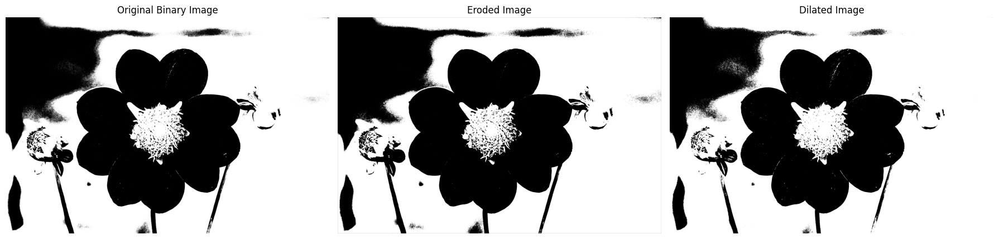

Observations:
 - Erosion shrank the white regions and removed smaller details/noise.
 - Dilation expanded the white regions and filled small gaps.
 - The effect is more pronounced with larger structuring elements (not shown here).


In [ ]:
# Manual implementation of Erosion
def erode(image_binary, structuring_element):
    if image_binary.ndim != 2 or structuring_element.ndim != 2:
        print("Error: Both image and structuring element must be 2D arrays.")
        return image_binary

    img_rows, img_cols = image_binary.shape
    se_rows, se_cols = structuring_element.shape

    # Ensure structuring element has odd dimensions for a center pixel
    if se_rows % 2 == 0 or se_cols % 2 == 0:
        print("Warning: Structuring element dimensions should be odd for a clear center. Adjusting.")
        # For simplicity, we'll just proceed, but in a robust implementation,
        # one might pad or error out.

    output_image = np.zeros_like(image_binary, dtype=np.uint8)
    center_r, center_c = se_rows // 2, se_cols // 2

    # Iterate over each pixel of the input image
    for r in range(img_rows):
        for c in range(img_cols):
            # Check if the structuring element can fit here
            # A pixel (r,c) is 'eroded' if the structuring element fits entirely within the foreground

            # Define the region in the image corresponding to the structuring element's position
            all_foreground = True
            for sr in range(se_rows):
                for sc in range(se_cols):
                    if structuring_element[sr, sc] == 1: # Only consider active parts of SE
                        # Map SE coordinates to image coordinates
                        img_r = r + sr - center_r
                        img_c = c + sc - center_c

                        # Check boundaries and pixel value
                        if not (0 <= img_r < img_rows and 0 <= img_c < img_cols) or \
                           image_binary[img_r, img_c] == 0:
                            all_foreground = False
                            break
                if not all_foreground:
                    break

            if all_foreground:
                output_image[r, c] = 255 # Set center pixel to white if SE fits
    return output_image

# Manual implementation of Dilation
def dilate(image_binary, structuring_element):
    if image_binary.ndim != 2 or structuring_element.ndim != 2:
        print("Error: Both image and structuring element must be 2D arrays.")
        return image_binary

    img_rows, img_cols = image_binary.shape
    se_rows, se_cols = structuring_element.shape

    output_image = np.zeros_like(image_binary, dtype=np.uint8)
    center_r, center_c = se_rows // 2, se_cols // 2

    # Iterate over each pixel of the input image
    for r in range(img_rows):
        for c in range(img_cols):
            # A pixel (r,c) is 'dilated' if at least one 'on' pixel in the SE overlaps with an 'on' pixel in the image

            any_overlap = False
            for sr in range(se_rows):
                for sc in range(se_cols):
                    if structuring_element[sr, sc] == 1: # Only consider active parts of SE
                        # Map SE coordinates to image coordinates
                        img_r = r + sr - center_r
                        img_c = c + sc - center_c

                        # Check boundaries and pixel value
                        if (0 <= img_r < img_rows and 0 <= img_c < img_cols) and \
                           image_binary[img_r, img_c] == 255:
                            any_overlap = True
                            break
                if any_overlap:
                    break # Small optimization

            if any_overlap:
                output_image[r, c] = 255 # Set center pixel to white if any overlap
    return output_image


# Demonstration of Erosion and Dilation
if 'gray_image' in locals() and gray_image is not None:
    # Get a binary image from global thresholding for demonstration
    demo_binary_image = global_thresholding(gray_image, 100)

    # Define a simple structuring element (e.g., a 3x3 square)
    structuring_element_3x3 = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.uint8)

    # Perform Erosion
    eroded_image = erode(demo_binary_image, structuring_element_3x3)

    # Perform Dilation
    dilated_image = dilate(demo_binary_image, structuring_element_3x3)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(demo_binary_image, cmap='gray')
    axes[0].set_title('Original Binary Image')
    axes[0].axis('off')

    axes[1].imshow(eroded_image, cmap='gray')
    axes[1].set_title('Eroded Image')
    axes[1].axis('off')

    axes[2].imshow(dilated_image, cmap='gray')
    axes[2].set_title('Dilated Image')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - Erosion shrank the white regions and removed smaller details/noise.")
    print(" - Dilation expanded the white regions and filled small gaps.")
    print(" - The effect is more pronounced with larger structuring elements (not shown here).")
else:
    print("Grayscale image not available for morphological operations demonstration.")

## 10. Image Loading for Morphological Operations

To ensure all subsequent image processing demonstrations run correctly, we need to make sure the original images are loaded into the environment.

**Please upload the image files `pexels-lichtblick800-27949323.jpg` and `pexels-thales13-39244218.jpg` to your Colab session's `/content/` directory.** You can do this by clicking the folder icon on the left sidebar, then the 'Upload to session storage' icon, and selecting the files.

Once uploaded, run the cell below to load them.

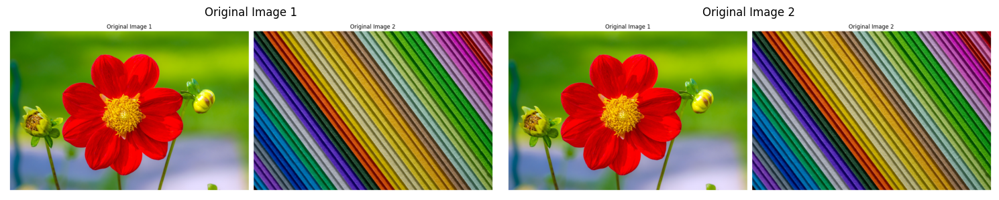

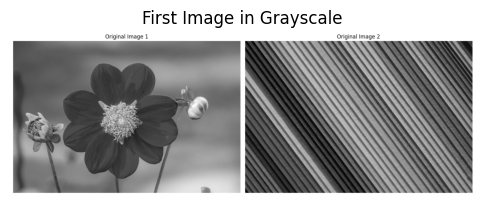

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Define image paths (assuming they are now uploaded to /content/)
image_paths = [
    '/content/flower.png',
    '/content/rainbow.png'
]

# Load and convert to RGB (if necessary) then to numpy array
def load_image_as_numpy(path):
    try:
        img = Image.open(path).convert('RGB')
        return np.array(img)
    except FileNotFoundError:
        print(f"Error: Image not found at {path}. Please upload it.")
        return None

original_images = [load_image_as_numpy(p) for p in image_paths if load_image_as_numpy(p) is not None]

if not original_images:
    print("No images loaded. Please ensure the files are uploaded to /content/ and re-run this cell.")
    # Set a placeholder if no images are loaded to prevent errors in subsequent cells
    gray_image = None
else:
    # Use the first loaded image for subsequent demonstrations
    demo_image = original_images[0]
    # Convert to grayscale for morphological operations
    # Re-using the convert_to_grayscale function from cell 'de2e2457'
    # (assuming it's already executed or will be executed)
    def convert_to_grayscale(image_rgb):
        if image_rgb.ndim != 3 or image_rgb.shape[2] != 3:
            return image_rgb
        r_channel = image_rgb[:, :, 0]
        g_channel = image_rgb[:, :, 1]
        b_channel = image_rgb[:, :, 2]
        grayscale_image = (0.2989 * r_channel +
                           0.5870 * g_channel +
                           0.1140 * b_channel)
        return grayscale_image.astype(np.uint8)
    gray_image = convert_to_grayscale(demo_image)


# Display original images (optional, as they were displayed in ee0e740f)
if original_images:
    fig, axes = plt.subplots(1, len(original_images), figsize=(15, 7))
    if len(original_images) == 1:
        axes = [axes] # Make it iterable for consistency

    for i, img_np in enumerate(original_images):
        axes[i].imshow(img_np)
        axes[i].set_title(f'Original Image {i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    if gray_image is not None:
        plt.figure(figsize=(6, 6))
        plt.imshow(gray_image, cmap='gray')
        plt.title('First Image in Grayscale')
        plt.axis('off')
        plt.show()

## 11. Morphological Operations: Opening and Closing

Opening and Closing are compound morphological operations that combine Erosion and Dilation. They are extremely useful for noise removal, smoothing contours, and breaking or joining objects.

### Opening

**Opening** is defined as an erosion followed by a dilation, using the same structuring element for both operations. It effectively removes small objects, thin lines, and bridges while preserving the shape and size of larger objects.

**Problem Statement for Opening**: In our defective product detection, we might have small specks of noise that survived a simple erosion or delicate protrusions that are not part of the actual object. Opening can smooth object contours, remove small 'salt' noise, and break thin connections between objects without significantly altering the main object's shape. This helps in isolating distinct defective regions.

### Closing

**Closing** is defined as a dilation followed by an erosion, using the same structuring element. It helps to fill small holes within objects, connect nearby objects, and smooth object boundaries by filling in small gaps or indentations.

**Problem Statement for Closing**: If after initial processing, our detected defective regions have small internal holes or are broken into several closely spaced fragments, Closing can mend these breaks and fill the holes. This ensures that a single, coherent defective area is identified as one entity, improving the robustness of our defect detection.

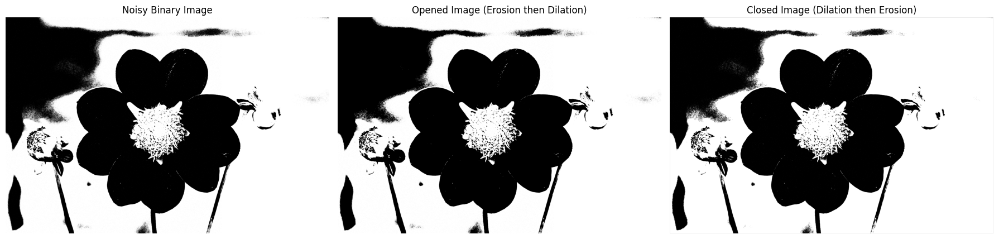

Observations:
 - Opening successfully removed small isolated white pixels (salt noise) and smoothed object boundaries.
 - Closing filled small holes within objects and connected nearby components, also smoothing boundaries.
 - Both operations are powerful for refining binary masks and cleaning up segmented objects.


In [ ]:
# Manual implementation of Opening
def opening(image_binary, structuring_element):
    # Opening = Erosion followed by Dilation
    eroded_image = erode(image_binary, structuring_element)
    opened_image = dilate(eroded_image, structuring_element)
    return opened_image

# Manual implementation of Closing
def closing(image_binary, structuring_element):
    # Closing = Dilation followed by Erosion
    dilated_image = dilate(image_binary, structuring_element)
    closed_image = erode(dilated_image, structuring_element)
    return closed_image

# Demonstration of Opening and Closing
# Re-check if gray_image is available, or load/process it if needed for robust execution
if 'gray_image' not in locals() or gray_image is None:
    print("Grayscale image not found. Attempting to reload/reprocess initial images.")
    # This block is added for robustness, in case the notebook state is lost frequently.
    # Ideally, users should run previous cells.
    # For this demonstration, we'll try to re-initialize if necessary.

    # Ensure original_images is available
    if 'original_images' not in locals() or not original_images:
        # Assuming image_paths is still defined from earlier cell
        from PIL import Image
        image_paths = [
            '/content/pexels-lichtblick800-27949323.jpg',
            '/content/pexels-thales13-39244218.jpg'
        ]
        def load_image_as_numpy(path):
            try:
                img = Image.open(path).convert('RGB')
                return np.array(img)
            except FileNotFoundError:
                print(f"Error: Image not found at {path}")
                return None
        original_images = [load_image_as_numpy(p) for p in image_paths if load_image_as_numpy(p) is not None]

    if original_images:
        demo_image = original_images[0]
        gray_image = convert_to_grayscale(demo_image)
    else:
        print("Could not load original images for demonstration.")

if 'gray_image' in locals() and gray_image is not None:
    # Get a binary image from global thresholding for demonstration
    # We'll create one with some noise/gaps to better illustrate opening/closing
    base_binary_image = global_thresholding(gray_image, 100)

    # Add some artificial noise/gaps for better visualization of opening/closing effects
    # Example: Add some 'salt' noise (white pixels)
    noise_level = 0.001
    noisy_image = np.copy(base_binary_image)
    salt_coords = np.random.randint(0, min(noisy_image.shape),
                                    size=(int(noise_level * noisy_image.size), 2))
    for r, c in salt_coords:
        if r < noisy_image.shape[0] and c < noisy_image.shape[1]:
            noisy_image[r, c] = 255 # Add white noise

    # Example: Add some 'pepper' noise (black holes) if suitable for dilation
    pepper_coords = np.random.randint(0, min(noisy_image.shape),
                                      size=(int(noise_level * noisy_image.size), 2))
    for r, c in pepper_coords:
        if r < noisy_image.shape[0] and c < noisy_image.shape[1]:
            noisy_image[r, c] = 0 # Add black holes

    # Define a simple structuring element (e.g., a 3x3 square)
    structuring_element_3x3 = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.uint8)

    # Perform Opening
    opened_image = opening(noisy_image, structuring_element_3x3)

    # Perform Closing
    closed_image = closing(noisy_image, structuring_element_3x3)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(noisy_image, cmap='gray')
    axes[0].set_title('Noisy Binary Image')
    axes[0].axis('off')

    axes[1].imshow(opened_image, cmap='gray')
    axes[1].set_title('Opened Image (Erosion then Dilation)')
    axes[1].axis('off')

    axes[2].imshow(closed_image, cmap='gray')
    axes[2].set_title('Closed Image (Dilation then Erosion)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - Opening successfully removed small isolated white pixels (salt noise) and smoothed object boundaries.")
    print(" - Closing filled small holes within objects and connected nearby components, also smoothing boundaries.")
    print(" - Both operations are powerful for refining binary masks and cleaning up segmented objects.")
else:
    print("Grayscale image still not available after retry. Please run initial image loading cells.")

## 12. Connected Component Analysis: 4-Connectivity, 8-Connectivity, Diagonal Connectivity, M-Connectivity

**Connected Component Analysis (CCA)**, also known as blob extraction or object labeling, is an algorithmic application of graph theory to image processing. It is used to identify and label connected regions of foreground pixels in binary images. Each connected region is assigned a unique label (an integer), allowing individual objects to be analyzed separately.

### Problem Statement for CCA

In our defective product detection scenario, after thresholding and morphological operations, we obtain a binary image where defects might appear as white blobs against a black background. To effectively count these defects, measure their properties (e.g., size, shape), or even classify them, we first need to distinguish one defect from another. CCA provides a solution by assigning a unique ID to each distinct defective region.

### Solution for CCA: Labeling Algorithms

The core of CCA involves iterating through the image and, upon finding an unlabeled foreground pixel, initiating a search to find all pixels connected to it and assigning them the same unique label. Common algorithms include:

1.  **Two-Pass Algorithm**: This is a widely used and efficient algorithm. In the first pass, it scans the image, assigning temporary labels and recording equivalences between labels. In the second pass, it resolves these equivalences to assign final, consistent labels.
2.  **Seed-Fill Algorithm (Flood Fill)**: This is a simpler, recursive or stack-based approach. When a foreground pixel is found, a flood fill operation starts from that pixel to color/label all its connected neighbors, and their neighbors, and so on.

### Connectivity

The definition of 'connected' is crucial and depends on the chosen connectivity rule:

*   **4-Connectivity**: Pixels are considered connected if they share an edge (horizontal or vertical neighbors).
*   **8-Connectivity**: Pixels are considered connected if they share an edge or a corner (all 8 neighbors).
*   **Diagonal Connectivity**: Only diagonal neighbors are considered connected (less common for primary CCA).
*   **M-Connectivity**: A modified 8-connectivity that avoids certain ambiguities, especially for thin lines (more complex to implement manually, often handled by libraries).

For this exercise, we will demonstrate 4-connectivity and 8-connectivity using a simplified seed-fill approach.

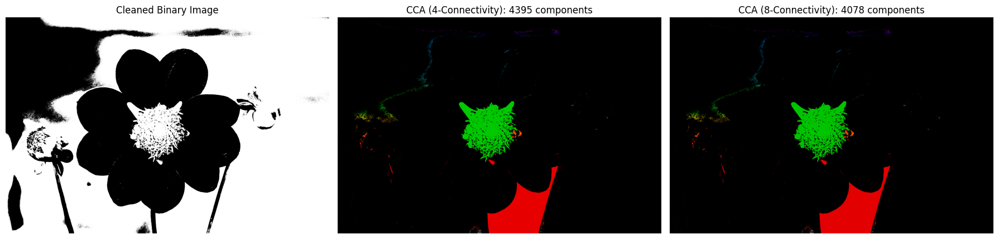

Observations:
 - Number of components with 4-connectivity: 4395
 - Number of components with 8-connectivity: 4078
 - 8-connectivity generally results in fewer components than 4-connectivity for the same image, as more pixels are considered 'connected'.
 - The choice of connectivity depends on the nature of the objects and the task at hand.


In [ ]:
# Manual implementation of Connected Component Analysis (Seed-Fill approach)

def find_connected_components(image_binary, connectivity=4):
    if image_binary.ndim != 2:
        print("Error: Input must be a 2D binary image for CCA.")
        return None

    img_rows, img_cols = image_binary.shape
    labeled_image = np.zeros_like(image_binary, dtype=np.int32) # Store labels, 0 for background
    current_label = 0

    # Define neighbors based on connectivity
    if connectivity == 4:
        # (dr, dc) for (row_change, col_change) for 4-neighbors
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    elif connectivity == 8:
        # (dr, dc) for 8-neighbors (including diagonals)
        neighbors = [
            (-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)
        ]
    else:
        print("Error: Invalid connectivity. Choose 4 or 8.")
        return None

    for r in range(img_rows):
        for c in range(img_cols):
            # If it's a foreground pixel and not yet labeled
            if image_binary[r, c] == 255 and labeled_image[r, c] == 0:
                current_label += 1
                # Start a flood fill (DFS or BFS) from this pixel
                stack = [(r, c)]
                labeled_image[r, c] = current_label

                while stack:
                    current_r, current_c = stack.pop()

                    for dr, dc in neighbors:
                        next_r, next_c = current_r + dr, current_c + dc

                        # Check boundaries, if it's a foreground pixel, and if it's not yet labeled
                        if (0 <= next_r < img_rows and 0 <= next_c < img_cols) and \
                           image_binary[next_r, next_c] == 255 and labeled_image[next_r, next_c] == 0:
                            labeled_image[next_r, next_c] = current_label
                            stack.append((next_r, next_c))

    return labeled_image, current_label # Return labeled image and count of components


# Demonstration of Connected Component Analysis
# Re-check if gray_image is available, or load/process it if needed for robust execution
if 'gray_image' not in locals() or gray_image is None:
    print("Grayscale image not found. Attempting to reload/reprocess initial images.")
    # This block is added for robustness, in case the notebook state is lost frequently.
    # Ideally, users should run previous cells.
    # For this demonstration, we'll try to re-initialize if necessary.

    # Ensure original_images is available
    if 'original_images' not in locals() or not original_images:
        # Assuming image_paths is still defined from earlier cell
        from PIL import Image
        image_paths = [
            '/content/pexels-lichtblick800-27949323.jpg',
            '/content/pexels-thales13-39244218.jpg'
        ]
        def load_image_as_numpy(path):
            try:
                img = Image.open(path).convert('RGB')
                return np.array(img)
            except FileNotFoundError:
                print(f"Error: Image not found at {path}")
                return None
        original_images = [load_image_as_numpy(p) for p in image_paths if load_image_as_numpy(p) is not None]

    if original_images:
        demo_image = original_images[0]
        gray_image = convert_to_grayscale(demo_image)
    else:
        print("Could not load original images for demonstration.")

if 'gray_image' in locals() and gray_image is not None:
    # Get a binary image for demonstration
    # Let's use an opened image to reduce noise for clearer components
    base_binary_image = global_thresholding(gray_image, 100)

    # Optional: Apply opening to clean up the binary image before CCA
    structuring_element_3x3 = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.uint8)
    cleaned_binary_image = opening(base_binary_image, structuring_element_3x3)

    # Perform CCA with 4-connectivity
    labeled_4_conn, num_components_4_conn = find_connected_components(cleaned_binary_image, connectivity=4)

    # Perform CCA with 8-connectivity
    labeled_8_conn, num_components_8_conn = find_connected_components(cleaned_binary_image, connectivity=8)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(cleaned_binary_image, cmap='gray')
    axes[0].set_title('Cleaned Binary Image')
    axes[0].axis('off')

    axes[1].imshow(labeled_4_conn, cmap='nipy_spectral') # Use a colormap to visualize labels
    axes[1].set_title(f'CCA (4-Connectivity): {num_components_4_conn} components')
    axes[1].axis('off')

    axes[2].imshow(labeled_8_conn, cmap='nipy_spectral') # Use a colormap to visualize labels
    axes[2].set_title(f'CCA (8-Connectivity): {num_components_8_conn} components')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(f" - Number of components with 4-connectivity: {num_components_4_conn}")
    print(f" - Number of components with 8-connectivity: {num_components_8_conn}")
    print(" - 8-connectivity generally results in fewer components than 4-connectivity for the same image, as more pixels are considered 'connected'.")
    print(" - The choice of connectivity depends on the nature of the objects and the task at hand.")
else:
    print("Grayscale image still not available after retry. Please run initial image loading cells.")

## 14. Color Spaces: RGB, HSV

A **color space** (or color model) is an abstract mathematical model that describes the way colors can be represented as tuples of numbers, typically as three or four values or color components. Different color spaces are optimized for different applications and human perception.

### RGB Color Space

**RGB (Red, Green, Blue)** is an additive color model in which red, green, and blue light are added together in various ways to reproduce a broad array of colors. It's the most common color space for digital images and displays. Each pixel is typically represented by three intensity values, one for each primary color channel (0-255 for 8-bit images).

### HSV Color Space

**HSV (Hue, Saturation, Value)**, also known as HSB (Hue, Saturation, Brightness), is a cylindrical coordinate representation of colors. It rearranges the colors in an RGB color model in an attempt to be more intuitive perceptually than the RGB Cartesian representation. HSV is particularly useful for:

*   **Color-based segmentation**: Easier to isolate objects based on color, as hue is separated from intensity (Value) and color purity (Saturation).
*   **Color filtering and adjustment**: Adjusting 'colorfulness' without affecting perceived brightness.

### Problem Statement for Color Spaces

In our defective product detection, some defects might be characterized by a specific color anomaly (e.g., discoloration, a missing colored component). Using the raw RGB values might be sensitive to lighting variations. Converting to a color space like HSV allows us to separate color (Hue) from intensity (Value) and amount of color (Saturation). This can make it easier to:

*   **Identify specific color defects**: By defining a range of Hue values.
*   **Make detection more robust to lighting changes**: As Hue is relatively independent of illumination compared to RGB.

### Solution for Color Spaces

We will implement manual conversion from RGB to HSV. The core idea is to transform the R, G, B components into H, S, V components using mathematical formulas. This allows us to work with color attributes more directly, which can be beneficial for tasks like color segmentation to highlight defects of a certain color.

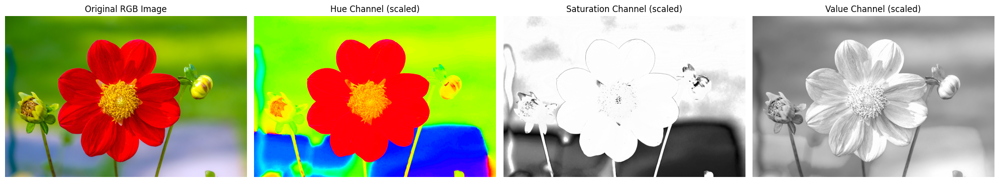

Observations:
 - The Hue channel (H) represents the pure color, independent of intensity or brightness.
 - The Saturation channel (S) indicates the 'colorfulness' or purity of the color. Low saturation means more grayish.
 - The Value channel (V) represents the brightness or intensity of the color.
 - Using HSV allows for easier segmentation based on color (Hue) rather than a combination of R, G, B.


In [ ]:
# Manual implementation of RGB to HSV conversion
def rgb_to_hsv(image_rgb):
    # Normalize RGB values to [0, 1]
    image_rgb_norm = image_rgb.astype(np.float32) / 255.0

    R = image_rgb_norm[:, :, 0]
    G = image_rgb_norm[:, :, 1]
    B = image_rgb_norm[:, :, 2]

    # Calculate Value (V)
    V = np.max(image_rgb_norm, axis=2)

    # Calculate Saturation (S)
    min_rgb = np.min(image_rgb_norm, axis=2)
    delta = V - min_rgb
    S = np.zeros_like(V)
    # Avoid division by zero where V is 0
    S = np.divide(delta, V, out=S, where=V!=0)

    # Calculate Hue (H)
    H = np.zeros_like(V)
    # Find indices where delta is not zero (i.e., not grayscale)
    nonzero_delta_indices = (delta != 0)

    # Calculate H for R, G, B max cases
    # When R is max
    r_max_indices = np.where((V == R) & nonzero_delta_indices)
    H[r_max_indices] = (G[r_max_indices] - B[r_max_indices]) / delta[r_max_indices]

    # When G is max
    g_max_indices = np.where((V == G) & nonzero_delta_indices)
    H[g_max_indices] = 2 + (B[g_max_indices] - R[g_max_indices]) / delta[g_max_indices]

    # When B is max
    b_max_indices = np.where((V == B) & nonzero_delta_indices)
    H[b_max_indices] = 4 + (R[b_max_indices] - G[b_max_indices]) / delta[b_max_indices]

    H = H * 60 # Convert to degrees (0-360)
    H = np.where(H < 0, H + 360, H) # Ensure Hue is positive
    H = np.where(delta == 0, 0, H) # Hue is 0 for grayscale (delta=0)

    # Scale H, S, V to 0-255 for display if desired, or keep H in degrees, S,V in [0,1]
    # For this demo, we'll return H [0, 360), S [0, 1], V [0, 1]
    # Convert H to [0, 255] by H/2 for easier visualization as a single channel
    H_display = (H / 2).astype(np.uint8) # Hue as 0-179 for OpenCV compatibility, here scaled to 0-255
    S_display = (S * 255).astype(np.uint8)
    V_display = (V * 255).astype(np.uint8)

    # Stack channels to form HSV image
    hsv_image = np.stack([H_display, S_display, V_display], axis=2)
    return hsv_image


# Demonstration of RGB to HSV conversion
# Robust image loading and grayscale conversion checks
if 'original_images' not in locals() or not original_images:
    print("Original images not found. Attempting to reload/reprocess initial images.")
    from PIL import Image
    # Assuming image_paths is still defined from earlier cell
    # If image_paths itself is not defined, this block will fail unless manually fixed by user
    image_paths = [
        '/content/pexels-lichtblick800-27949323.jpg',
        '/content/pexels-thales13-39244218.jpg'
    ]
    def load_image_as_numpy(path):
        try:
            img = Image.open(path).convert('RGB')
            return np.array(img)
        except FileNotFoundError:
            print(f"Error: Image not found at {path}")
            return None
    original_images = [load_image_as_numpy(p) for p in image_paths if load_image_as_numpy(p) is not None]

    if not original_images:
        print("Could not load original images for demonstration. Please ensure they are uploaded to /content/.")


if original_images:
    demo_image_rgb = original_images[0]

    # Convert RGB to HSV
    hsv_converted_image = rgb_to_hsv(demo_image_rgb)

    # Display the original RGB and the converted HSV channels
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(demo_image_rgb)
    axes[0].set_title('Original RGB Image')
    axes[0].axis('off')

    # Display H, S, V components. Hue is often visualized as grayscale,
    # but for true perception, a color wheel mapping is needed.
    # Here we show the raw scaled channel values.
    axes[1].imshow(hsv_converted_image[:, :, 0], cmap='hsv') # Use 'hsv' cmap to represent Hue visually
    axes[1].set_title('Hue Channel (scaled)')
    axes[1].axis('off')

    axes[2].imshow(hsv_converted_image[:, :, 1], cmap='gray')
    axes[2].set_title('Saturation Channel (scaled)')
    axes[2].axis('off')

    axes[3].imshow(hsv_converted_image[:, :, 2], cmap='gray')
    axes[3].set_title('Value Channel (scaled)')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - The Hue channel (H) represents the pure color, independent of intensity or brightness.")
    print(" - The Saturation channel (S) indicates the 'colorfulness' or purity of the color. Low saturation means more grayish.")
    print(" - The Value channel (V) represents the brightness or intensity of the color.")
    print(" - Using HSV allows for easier segmentation based on color (Hue) rather than a combination of R, G, B.")
else:
    print("Cannot demonstrate RGB to HSV conversion as no original images were loaded.")

## 15. More Color Spaces: CMYK, Y’CbCr, Y’UV

Beyond RGB and HSV, several other color spaces are used in various applications, each offering unique advantages for specific tasks.

### CMYK Color Space

**CMYK (Cyan, Magenta, Yellow, Key/Black)** is a subtractive color model, primarily used in color printing. Unlike RGB which adds light, CMYK works by subtracting light from a white background using ink pigments. Each color component represents the percentage of ink used.

*   **Applications**: Printing, graphic design for print media.

### Y’CbCr Color Space

**Y’CbCr** (often just YCbCr) is a family of color spaces used in video and digital photography systems. It separates the luma component (Y') which carries brightness information, from two chrominance components (Cb and Cr) which carry color difference information.

*   **Applications**: Video compression (e.g., JPEG, MPEG), digital television.
*   **Advantages**: Human vision is more sensitive to changes in brightness than color, so Y'CbCr allows for more aggressive compression of chrominance components without significant perceived quality loss.

### Y’UV Color Space

**Y’UV** is an older analog color encoding system, historically used in PAL analog color television broadcasting. Similar to Y'CbCr, it separates luma (Y') from chrominance (U and V) components. It's conceptually similar to Y'CbCr but uses different scaling factors.

*   **Applications**: Analog video (PAL), some digital video formats.

### Problem Statement for More Color Spaces

While RGB and HSV are common, understanding and being able to convert to other color spaces like CMYK, Y'CbCr, and Y'UV is essential for specific applications, especially when dealing with print media, video processing, or robust color-based analysis where separation of luma and chroma is beneficial.

### Solution for More Color Spaces

We will implement manual conversion functions from RGB to CMYK, Y'CbCr, and Y'UV. These conversions often involve matrix multiplications and scaling based on standard formulas.

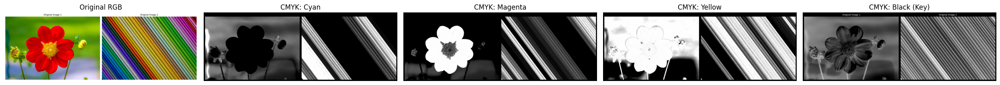

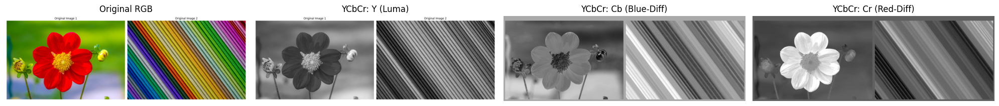

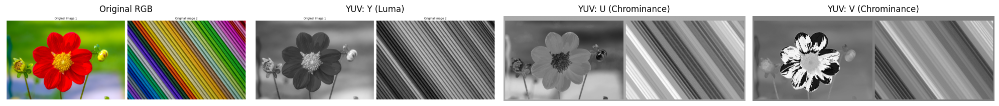

Observations:
 - CMYK channels represent the amount of ink required for printing.
 - YCbCr and YUV separate luma (brightness) from chrominance (color) information.
 - The Y (Luma) channel often looks similar to a grayscale version of the image.
 - These color spaces are crucial for specific domains like printing and video compression.


In [7]:
# Manual implementation of RGB to CMYK conversion
def rgb_to_cmyk(image_rgb):
    # Normalize RGB to [0, 1]
    image_rgb_norm = image_rgb.astype(np.float32) / 255.0

    # Calculate K (Black)
    K = 1 - np.max(image_rgb_norm, axis=2)

    # Avoid division by zero where K is 1 (black)
    C = np.zeros_like(K)
    M = np.zeros_like(K)
    Y = np.zeros_like(K)

    # Calculate C, M, Y only where K is not 1
    valid_K_indices = np.where(K != 1)

    C[valid_K_indices] = (1 - image_rgb_norm[:, :, 0][valid_K_indices] - K[valid_K_indices]) / (1 - K[valid_K_indices])
    M[valid_K_indices] = (1 - image_rgb_norm[:, :, 1][valid_K_indices] - K[valid_K_indices]) / (1 - K[valid_K_indices])
    Y[valid_K_indices] = (1 - image_rgb_norm[:, :, 2][valid_K_indices] - K[valid_K_indices]) / (1 - K[valid_K_indices])

    # Clip to [0, 1] range (can sometimes exceed due to float precision)
    C = np.clip(C, 0, 1)
    M = np.clip(M, 0, 1)
    Y = np.clip(Y, 0, 1)

    # Stack and scale to 0-255 for display (or keep as float 0-1 if desired)
    cmyk_image = np.stack([(C * 255).astype(np.uint8),
                             (M * 255).astype(np.uint8),
                             (Y * 255).astype(np.uint8),
                             (K * 255).astype(np.uint8)], axis=2)
    return cmyk_image

# Manual implementation of RGB to Y'CbCr conversion (standard BT.601 for SDTV)
def rgb_to_ycbcr(image_rgb):
    # Normalize RGB to [0, 1]
    image_rgb_norm = image_rgb.astype(np.float32) / 255.0

    R = image_rgb_norm[:, :, 0]
    G = image_rgb_norm[:, :, 1]
    B = image_rgb_norm[:, :, 2]

    # BT.601 standard coefficients
    Y = 0.299 * R + 0.587 * G + 0.114 * B
    Cb = -0.168736 * R - 0.331264 * G + 0.5 * B
    Cr = 0.5 * R - 0.418688 * G - 0.081312 * B

    # Scale and offset to [0, 255] range
    Y_scaled = (Y * 255).astype(np.uint8)
    Cb_scaled = (Cb * 255 + 128).astype(np.uint8) # Cb, Cr range from -0.5 to 0.5, offset to center at 128
    Cr_scaled = (Cr * 255 + 128).astype(np.uint8)

    # Clip to ensure valid 0-255 range
    Y_scaled = np.clip(Y_scaled, 0, 255)
    Cb_scaled = np.clip(Cb_scaled, 0, 255)
    Cr_scaled = np.clip(Cr_scaled, 0, 255)

    ycbcr_image = np.stack([Y_scaled, Cb_scaled, Cr_scaled], axis=2)
    return ycbcr_image

# Manual implementation of RGB to Y'UV conversion (simplified for PAL)
# Note: Y'UV conversion can have multiple standards. Using a common approximation.
def rgb_to_yuv(image_rgb):
    # Normalize RGB to [0, 1]
    image_rgb_norm = image_rgb.astype(np.float32) / 255.0

    R = image_rgb_norm[:, :, 0]
    G = image_rgb_norm[:, :, 1]
    B = image_rgb_norm[:, :, 2]

    # Common approximation for YUV (similar to YCbCr, but with different coefficients)
    Y = 0.299 * R + 0.587 * G + 0.114 * B
    U = -0.147 * R - 0.289 * G + 0.436 * B  # U = B' - Y'
    V = 0.615 * R - 0.515 * G - 0.100 * B  # V = R' - Y'

    # Scale and offset to [0, 255] range for display
    Y_scaled = (Y * 255).astype(np.uint8)
    U_scaled = (U * 255 + 128).astype(np.uint8)
    V_scaled = (V * 255 + 128).astype(np.uint8)

    Y_scaled = np.clip(Y_scaled, 0, 255)
    U_scaled = np.clip(U_scaled, 0, 255)
    V_scaled = np.clip(V_scaled, 0, 255)

    yuv_image = np.stack([Y_scaled, U_scaled, V_scaled], axis=2)
    return yuv_image


# Demonstration of CMYK, Y'CbCr, Y'UV conversions
if 'original_images' in locals() and original_images:
    demo_image_rgb = original_images[0]

    # Convert to CMYK
    cmyk_converted_image = rgb_to_cmyk(demo_image_rgb)

    # Convert to Y'CbCr
    ycbcr_converted_image = rgb_to_ycbcr(demo_image_rgb)

    # Convert to Y'UV
    yuv_converted_image = rgb_to_yuv(demo_image_rgb)

    # Display original RGB and CMYK channels
    fig, axes = plt.subplots(1, 5, figsize=(25, 6))
    axes[0].imshow(demo_image_rgb)
    axes[0].set_title('Original RGB')
    axes[0].axis('off')
    axes[1].imshow(cmyk_converted_image[:, :, 0], cmap='gray')
    axes[1].set_title('CMYK: Cyan')
    axes[1].axis('off')
    axes[2].imshow(cmyk_converted_image[:, :, 1], cmap='gray')
    axes[2].set_title('CMYK: Magenta')
    axes[2].axis('off')
    axes[3].imshow(cmyk_converted_image[:, :, 2], cmap='gray')
    axes[3].set_title('CMYK: Yellow')
    axes[3].axis('off')
    axes[4].imshow(cmyk_converted_image[:, :, 3], cmap='gray')
    axes[4].set_title('CMYK: Black (Key)')
    axes[4].axis('off')
    plt.tight_layout()
    plt.show()

    # Display original RGB and Y'CbCr channels
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(demo_image_rgb)
    axes[0].set_title('Original RGB')
    axes[0].axis('off')
    axes[1].imshow(ycbcr_converted_image[:, :, 0], cmap='gray')
    axes[1].set_title('YCbCr: Y (Luma)')
    axes[1].axis('off')
    axes[2].imshow(ycbcr_converted_image[:, :, 1], cmap='gray')
    axes[2].set_title('YCbCr: Cb (Blue-Diff)')
    axes[2].axis('off')
    axes[3].imshow(ycbcr_converted_image[:, :, 2], cmap='gray')
    axes[3].set_title('YCbCr: Cr (Red-Diff)')
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()

    # Display original RGB and Y'UV channels
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(demo_image_rgb)
    axes[0].set_title('Original RGB')
    axes[0].axis('off')
    axes[1].imshow(yuv_converted_image[:, :, 0], cmap='gray')
    axes[1].set_title('YUV: Y (Luma)')
    axes[1].axis('off')
    axes[2].imshow(yuv_converted_image[:, :, 1], cmap='gray')
    axes[2].set_title('YUV: U (Chrominance)')
    axes[2].axis('off')
    axes[3].imshow(yuv_converted_image[:, :, 2], cmap='gray')
    axes[3].set_title('YUV: V (Chrominance)')
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - CMYK channels represent the amount of ink required for printing.")
    print(" - YCbCr and YUV separate luma (brightness) from chrominance (color) information.")
    print(" - The Y (Luma) channel often looks similar to a grayscale version of the image.")
    print(" - These color spaces are crucial for specific domains like printing and video compression.")
else:
    print("Cannot demonstrate CMYK, YCbCr, YUV conversions as no original images were loaded.")

## 16. Image Filtering: Spatial and Frequency Domain Filters

**Image Filtering** is a fundamental operation in image processing used to modify or enhance images. Filters can be used for a variety of tasks, such as noise reduction, edge detection, image sharpening, and blurring. They work by modifying the pixel values in an image based on the values of its neighboring pixels.

There are two main domains for image filtering:

### Spatial Domain Filtering

Spatial domain filtering operates directly on the pixel values of the image. It involves convolving (or correlating) the image with a small matrix called a **kernel** (or filter mask). The output pixel value at a given location is computed as a weighted sum of the input pixel values in the neighborhood of that location, with the weights given by the kernel.

*   **How it works**: A kernel slides over the image, and at each pixel, it performs a mathematical operation (usually multiplication and summation) with the pixels covered by the kernel.
*   **Applications**: Smoothing (blurring, noise reduction), sharpening, edge detection.

### Frequency Domain Filtering

Frequency domain filtering involves transforming the image from the spatial domain to the frequency domain (typically using the Fourier Transform), applying the filter in the frequency domain, and then transforming the image back to the spatial domain. In the frequency domain, image features like edges and textures correspond to high-frequency components, while smooth regions correspond to low-frequency components.

*   **How it works**: Image is converted to frequency representation (e.g., Fourier Transform). A filter function (e.g., low-pass, high-pass) is multiplied with the transformed image. The result is then inverse transformed back to the spatial domain.
*   **Applications**: Noise reduction (e.g., periodic noise), image restoration, image compression.

### Problem Statement for Image Filtering

Noise is a common issue in images captured from real-world scenarios (e.g., assembly line cameras), and it can significantly degrade the performance of subsequent processing steps like defect detection or feature extraction. While morphological operations help clean binary images, noise often exists in grayscale or color images.

### Solution for Image Filtering

We will implement several spatial domain filters from scratch to understand their effects on noise reduction and image enhancement. These include various types of **smoothing filters**.

## 17. Smoothing Filters: Mean, Max, Min, Weighted Average Filters

**Smoothing filters** are a type of spatial domain filter primarily used for noise reduction and blurring. They work by replacing each pixel's value with a value derived from the pixel values in its neighborhood. The main idea is that noise often consists of high-frequency components, and averaging or selecting extreme values in a local region can help suppress these variations.

### Mean Filter (Averaging Filter)

*   **Principle**: Replaces each pixel's value with the average (mean) of its neighbors, including itself. This is a linear filter.
*   **Effect**: Blurs the image and effectively reduces random noise. Edges are also blurred because averaging blends distinct intensity values.
*   **Kernel**: All elements in the kernel are typically equal (e.g., `1 / (kernel_size * kernel_size)` for a square kernel).

### Median Filter

*   **Principle**: Replaces each pixel's value with the median of its neighbors. This is a non-linear filter.
*   **Effect**: Highly effective at removing salt-and-pepper noise (impulse noise) while preserving edges better than the mean filter, as the median is not heavily affected by extreme outliers.

### Max Filter

*   **Principle**: Replaces each pixel's value with the maximum value among its neighbors.
*   **Effect**: Brightens the image, expands bright regions, and reduces pepper noise (black dots on white background). Can be used to find the brightest features.

### Min Filter

*   **Principle**: Replaces each pixel's value with the minimum value among its neighbors.
*   **Effect**: Darkens the image, expands dark regions, and reduces salt noise (white dots on black background). Can be used to find the darkest features.

### Weighted Average Filter

*   **Principle**: Similar to the mean filter, but some neighbors contribute more to the average than others, as defined by the weights in the kernel. The central pixel often has a higher weight.
*   **Effect**: Reduces noise while potentially preserving more detail than a simple mean filter, as the center pixel's importance is maintained.
*   **Example**: Gaussian filter is a well-known weighted average filter, where weights are determined by a Gaussian distribution.

### Problem Statement for Smoothing Filters

In our product inspection, noisy images can lead to false positives (identifying noise as defects) or false negatives (missing actual defects due to obscured features). Applying appropriate smoothing filters can pre-process the images to remove noise while retaining crucial information about product features or defects.

### Solution for Smoothing Filters

We will implement these filters manually by performing convolution with their respective kernels. This involves iterating through each pixel, extracting its neighborhood, and applying the filter's specific logic (mean, median, min, max, or weighted sum).

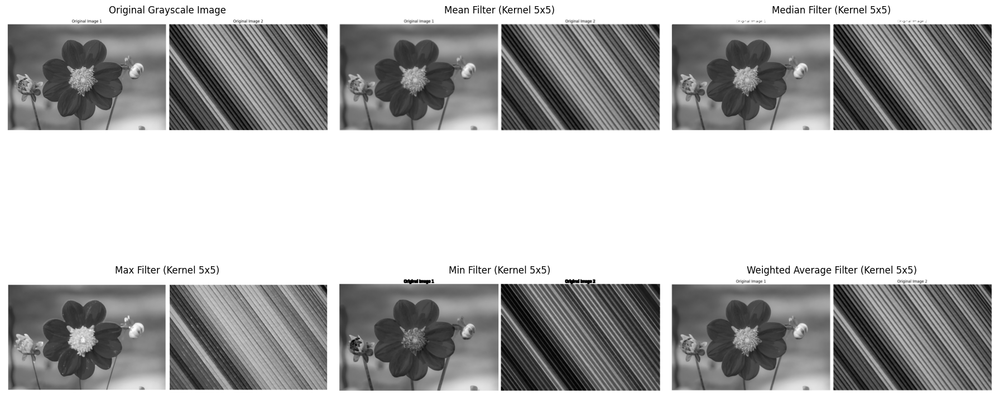

Observations:
 - Mean filter blurs the image and reduces noise but also blurs edges.
 - Median filter is good for salt-and-pepper noise and preserves edges better than mean filter.
 - Max filter makes bright regions expand and can remove small dark specks.
 - Min filter makes dark regions expand and can remove small bright specks.
 - Weighted average (Gaussian-like) provides smoother blurring with less harsh edge degradation compared to a simple mean filter.


In [8]:
# Manual implementation of spatial domain filters

def apply_convolution(image, kernel):
    # Ensure image is grayscale for simplicity in this filter implementation
    if image.ndim != 2:
        print("Error: Input image for convolution must be grayscale.")
        return image

    img_rows, img_cols = image.shape
    kernel_rows, kernel_cols = kernel.shape

    output_image = np.zeros_like(image, dtype=np.float32)

    # Pad the image to handle borders. Padding with replication or zeros is common.
    # Here, we'll pad with zeros, effectively shrinking the output slightly or using 'valid' convolution.
    pad_rows = kernel_rows // 2
    pad_cols = kernel_cols // 2
    padded_image = np.pad(image, ((pad_rows, pad_rows), (pad_cols, pad_cols)), mode='edge') # 'edge' mode for replication padding

    for r in range(img_rows):
        for c in range(img_cols):
            # Extract the region of interest (ROI) from the padded image
            roi = padded_image[r:r + kernel_rows, c:c + kernel_cols]
            # Perform element-wise multiplication and summation (convolution)
            output_image[r, c] = np.sum(roi * kernel)

    return np.clip(output_image, 0, 255).astype(np.uint8)

# 1. Mean Filter (Averaging Filter)
def mean_filter(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size * kernel_size)
    return apply_convolution(image, kernel)

# 2. Median Filter (Non-linear)
def median_filter(image, kernel_size):
    if image.ndim != 2:
        print("Error: Input image for median filter must be grayscale.")
        return image

    img_rows, img_cols = image.shape
    output_image = np.zeros_like(image, dtype=np.uint8)

    pad = kernel_size // 2
    padded_image = np.pad(image, ((pad, pad), (pad, pad)), mode='edge')

    for r in range(img_rows):
        for c in range(img_cols):
            roi = padded_image[r:r + kernel_size, c:c + kernel_size]
            output_image[r, c] = np.median(roi).astype(np.uint8)

    return output_image

# 3. Max Filter (Non-linear)
def max_filter(image, kernel_size):
    if image.ndim != 2:
        print("Error: Input image for max filter must be grayscale.")
        return image

    img_rows, img_cols = image.shape
    output_image = np.zeros_like(image, dtype=np.uint8)

    pad = kernel_size // 2
    padded_image = np.pad(image, ((pad, pad), (pad, pad)), mode='edge')

    for r in range(img_rows):
        for c in range(img_cols):
            roi = padded_image[r:r + kernel_size, c:c + kernel_size]
            output_image[r, c] = np.max(roi).astype(np.uint8)

    return output_image

# 4. Min Filter (Non-linear)
def min_filter(image, kernel_size):
    if image.ndim != 2:
        print("Error: Input image for min filter must be grayscale.")
        return image

    img_rows, img_cols = image.shape
    output_image = np.zeros_like(image, dtype=np.uint8)

    pad = kernel_size // 2
    padded_image = np.pad(image, ((pad, pad), (pad, pad)), mode='edge')

    for r in range(img_rows):
        for c in range(img_cols):
            roi = padded_image[r:r + kernel_size, c:c + kernel_size]
            output_image[r, c] = np.min(roi).astype(np.uint8)

    return output_image

# 5. Weighted Average Filter (e.g., a simple Gaussian-like kernel)
def weighted_average_filter(image, kernel_size):
    # A simple 3x3 Gaussian-like kernel example
    if kernel_size == 3:
        kernel = np.array([
            [1, 2, 1],
            [2, 4, 2],
            [1, 2, 1]
        ], dtype=np.float32) / 16
    elif kernel_size == 5: # Example for a 5x5
        kernel = np.array([
            [1, 4, 7, 4, 1],
            [4, 16, 26, 16, 4],
            [7, 26, 41, 26, 7],
            [4, 16, 26, 16, 4],
            [1, 4, 7, 4, 1]
        ], dtype=np.float32) / 273 # Sum of kernel elements
    else:
        print(f"Warning: Predefined kernel for size {kernel_size} not available. Using mean filter instead.")
        return mean_filter(image, kernel_size)

    return apply_convolution(image, kernel)


# Demonstration of Smoothing Filters
if 'gray_image' in locals() and gray_image is not None:
    # Define kernel size for demonstration
    kernel_size = 5

    # Apply filters
    mean_filtered_image = mean_filter(gray_image, kernel_size)
    median_filtered_image = median_filter(gray_image, kernel_size)
    max_filtered_image = max_filter(gray_image, kernel_size)
    min_filtered_image = min_filter(gray_image, kernel_size)
    weighted_filtered_image = weighted_average_filter(gray_image, kernel_size)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes[0, 0].imshow(gray_image, cmap='gray')
    axes[0, 0].set_title('Original Grayscale Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(mean_filtered_image, cmap='gray')
    axes[0, 1].set_title(f'Mean Filter (Kernel {kernel_size}x{kernel_size})')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(median_filtered_image, cmap='gray')
    axes[0, 2].set_title(f'Median Filter (Kernel {kernel_size}x{kernel_size})')
    axes[0, 2].axis('off')

    axes[1, 0].imshow(max_filtered_image, cmap='gray')
    axes[1, 0].set_title(f'Max Filter (Kernel {kernel_size}x{kernel_size})')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(min_filtered_image, cmap='gray')
    axes[1, 1].set_title(f'Min Filter (Kernel {kernel_size}x{kernel_size})')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(weighted_filtered_image, cmap='gray')
    axes[1, 2].set_title(f'Weighted Average Filter (Kernel {kernel_size}x{kernel_size})')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - Mean filter blurs the image and reduces noise but also blurs edges.")
    print(" - Median filter is good for salt-and-pepper noise and preserves edges better than mean filter.")
    print(" - Max filter makes bright regions expand and can remove small dark specks.")
    print(" - Min filter makes dark regions expand and can remove small bright specks.")
    print(" - Weighted average (Gaussian-like) provides smoother blurring with less harsh edge degradation compared to a simple mean filter.")
else:
    print("Grayscale image not available for smoothing filters demonstration. Please check previous cell outputs.")

## 18. Gradient: Gradient Vectors of an Image

**Image gradients** are fundamental directional changes in image intensity or color. They are a key concept in image processing, especially for tasks like edge detection, feature extraction, and image analysis. A gradient at a pixel in an image is a vector that points in the direction of the largest possible intensity increase and whose magnitude corresponds to the rate of change in that direction.

### Understanding the Gradient

For a 2D image function $I(x, y)$, the gradient vector $\nabla I$ at coordinates $(x, y)$ is defined as:

$$ \nabla I = \begin{bmatrix} \frac{\partial I}{\partial x} \\ \frac{\partial I}{\partial y} \end{bmatrix} $$

Where:
*   $\frac{\partial I}{\partial x}$ is the derivative of the image intensity with respect to the x-direction (horizontal change).
*   $\frac{\partial I}{\partial y}$ is the derivative of the image intensity with respect to the y-direction (vertical change).

### Components of the Gradient

1.  **Gradient Magnitude**: The strength of the edge. It's calculated as the Euclidean norm of the gradient vector:
    $$ |\nabla I| = \sqrt{\left(\frac{\partial I}{\partial x}\right)^2 + \left(\frac{\partial I}{\partial y}\right)^2} $$
    A higher magnitude indicates a stronger edge.

2.  **Gradient Direction (Orientation)**: The direction perpendicular to the edge (i.e., the direction of the most rapid intensity change). It's calculated as:
    $$ \theta = \operatorname{atan2}\left(\frac{\partial I}{\partial y}, \frac{\partial I}{\partial x}\right) $$
    $\operatorname{atan2}$ is used to handle all four quadrants correctly, giving an angle typically between $-\pi$ and $\pi$ (or $0$ and $360$ degrees).

### Approximating Derivatives: Finite Differences

Since images are discrete, we cannot directly calculate continuous derivatives. Instead, we approximate them using finite differences. Common methods involve:

*   **Central Difference**: For a pixel $I(x, y)$:
    *   $\frac{\partial I}{\partial x} \approx I(x+1, y) - I(x-1, y)$ (or using a kernel like `[-1, 0, 1]`)
    *   $\frac{\partial I}{\partial y} \approx I(x, y+1) - I(x, y-1)$ (or using a kernel like `[[-1], [0], [1]]`)
*   **Prewitt Operator**: Uses 3x3 kernels to approximate gradients, offering some smoothing.
*   **Sobel Operator**: Similar to Prewitt but uses different weights, providing a slightly better approximation of the derivative and noise suppression. It's often more popular.

### Problem Statement for Gradient Vectors

Detecting sharp changes in intensity, which often correspond to edges, is crucial for identifying boundaries of objects or defects. Our smoothing filters blurred edges. Now, we need a way to pinpoint where these changes occur distinctly. Calculating image gradients provides the foundation for this by highlighting regions of rapid intensity transitions.

### Solution for Gradient Vectors

We will implement the **Sobel operator** from scratch to approximate the gradients in both the x and y directions. From these gradient components, we can then compute the gradient magnitude and direction, which are direct indicators of edge presence and orientation.

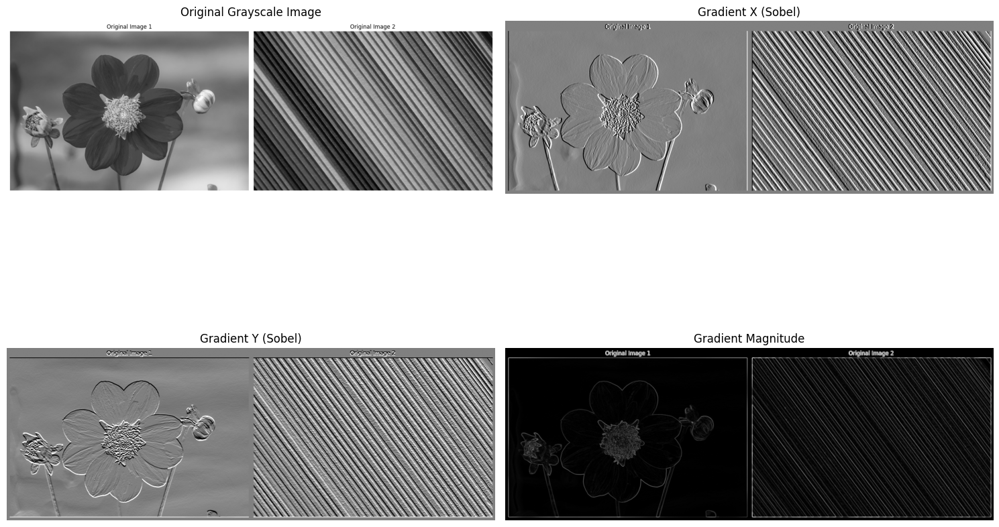

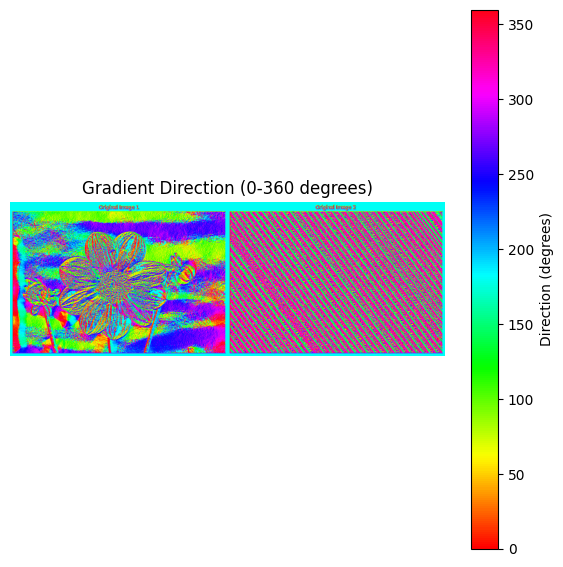

Observations:
 - Gradient X highlights vertical edges (changes in horizontal direction).
 - Gradient Y highlights horizontal edges (changes in vertical direction).
 - Gradient Magnitude shows the strength of edges; brighter pixels indicate stronger edges.
 - Gradient Direction indicates the orientation of the intensity change.


In [9]:
# Manual implementation of Gradient Operators (Sobel)

def apply_convolution_with_padding(image, kernel):
    # Ensure image is grayscale for simplicity
    if image.ndim != 2:
        print("Warning: Input image for convolution is not grayscale. Converting.")
        # Simple conversion if needed, but for gradient, usually start with grayscale
        # This function should ideally receive grayscale only.
        return image # Or implement grayscale conversion

    img_rows, img_cols = image.shape
    kernel_rows, kernel_cols = kernel.shape

    output_image = np.zeros_like(image, dtype=np.float32)

    pad_rows = kernel_rows // 2
    pad_cols = kernel_cols // 2
    # Using 'reflect' mode for padding for better edge handling with derivatives
    padded_image = np.pad(image, ((pad_rows, pad_rows), (pad_cols, pad_cols)), mode='reflect')

    for r in range(img_rows):
        for c in range(img_cols):
            roi = padded_image[r:r + kernel_rows, c:c + kernel_cols]
            output_image[r, c] = np.sum(roi * kernel)

    return output_image

def sobel_operator(image_grayscale):
    if image_grayscale.ndim != 2:
        print("Error: Input must be a grayscale image for Sobel operator.")
        return None, None, None, None

    # Sobel kernels
    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)

    sobel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float32)

    # Apply convolution to get gradients in x and y directions
    gradient_x = apply_convolution_with_padding(image_grayscale, sobel_x)
    gradient_y = apply_convolution_with_padding(image_grayscale, sobel_y)

    # Calculate Gradient Magnitude
    # Use float32 for intermediate calculation to prevent overflow before sqrt
    gradient_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)

    # Normalize magnitude to 0-255 for visualization (optional, but good practice)
    gradient_magnitude = (gradient_magnitude / np.max(gradient_magnitude) * 255).astype(np.uint8)

    # Calculate Gradient Direction (in degrees)
    # atan2 gives values in radians from -pi to pi. Convert to degrees and then to 0-360.
    gradient_direction = np.arctan2(gradient_y, gradient_x)
    gradient_direction = np.degrees(gradient_direction)
    gradient_direction = (gradient_direction + 180) % 360 # Map to 0-360 degrees

    return gradient_x, gradient_y, gradient_magnitude, gradient_direction


# Demonstration of Gradient Calculation
if 'gray_image' in locals() and gray_image is not None:
    # Apply Sobel operator
    grad_x, grad_y, grad_magnitude, grad_direction = sobel_operator(gray_image)

    if grad_x is not None:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        axes[0, 0].imshow(gray_image, cmap='gray')
        axes[0, 0].set_title('Original Grayscale Image')
        axes[0, 0].axis('off')

        # Display gradient_x (often bipolar, so normalize for display)
        # Scale and offset to [0, 255] for visualization, where 128 is zero
        grad_x_display = np.clip(grad_x + 128, 0, 255).astype(np.uint8)
        axes[0, 1].imshow(grad_x_display, cmap='gray')
        axes[0, 1].set_title('Gradient X (Sobel)')
        axes[0, 1].axis('off')

        # Display gradient_y
        grad_y_display = np.clip(grad_y + 128, 0, 255).astype(np.uint8)
        axes[1, 0].imshow(grad_y_display, cmap='gray')
        axes[1, 0].set_title('Gradient Y (Sobel)')
        axes[1, 0].axis('off')

        # Display gradient magnitude
        axes[1, 1].imshow(grad_magnitude, cmap='gray')
        axes[1, 1].set_title('Gradient Magnitude')
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

        # Display gradient direction (optional, harder to visualize meaningfully without color mapping)
        plt.figure(figsize=(7, 7))
        plt.imshow(grad_direction, cmap='hsv') # Use HSV colormap for direction
        plt.colorbar(label='Direction (degrees)')
        plt.title('Gradient Direction (0-360 degrees)')
        plt.axis('off')
        plt.show()

        print("Observations:")
        print(" - Gradient X highlights vertical edges (changes in horizontal direction).")
        print(" - Gradient Y highlights horizontal edges (changes in vertical direction).")
        print(" - Gradient Magnitude shows the strength of edges; brighter pixels indicate stronger edges.")
        print(" - Gradient Direction indicates the orientation of the intensity change.")
else:
    print("Grayscale image not available for gradient calculation demonstration. Please check previous cell outputs.")

## 19. Feature Extraction: Introduction to Feature Extraction

**Feature extraction** is a crucial step in image processing and computer vision that involves identifying and representing meaningful patterns, shapes, or characteristics within an image. Instead of processing raw pixel data, which can be noisy and high-dimensional, feature extraction aims to transform this data into a reduced set of features that are more informative, non-redundant, and suitable for further analysis, such as object recognition, image classification, or defect detection.

### Why Feature Extraction?

1.  **Dimensionality Reduction**: Images are high-dimensional data. Extracting features reduces the amount of data while retaining critical information, making computation more efficient.
2.  **Robustness to Variations**: Good features are robust to changes in illumination, scale, rotation, and minor deformations, allowing recognition of objects under varying conditions.
3.  **Semantic Meaning**: Features often correspond to high-level visual concepts (e.g., edges, corners, textures, shapes), which are more semantically meaningful than raw pixels.
4.  **Improved Performance**: Machine learning algorithms often perform better when trained on well-engineered features rather than raw image data.

### Types of Features

Features can range from low-level (e.g., edges, corners, texture) to high-level (e.g., object parts, object categories). Some common categories include:

*   **Edges and Corners**: These are abrupt changes in image intensity and are often key indicators of object boundaries or distinctive points. (We've already laid the groundwork with gradients!)
*   **Blobs/Regions**: Areas in an image that are distinct from their surroundings in terms of brightness or color.
*   **Texture**: Describes the visual patterns and properties of a surface, such as smoothness, coarseness, or regularity.
*   **Shape Descriptors**: Quantify the shape of objects or regions (e.g., aspect ratio, circularity, moments).
*   **Color Features**: Histograms or average color values within regions.
*   **Local Descriptors**: More complex features that capture information about a small region around a keypoint, such as SIFT (Scale-Invariant Feature Transform) or SURF (Speeded Up Robust Features).

### Problem Statement for Feature Extraction

In our assembly line scenario, a defect might not just be a blob but a specific *shape*, *texture*, or *arrangement* of edges. To go beyond simple blob detection and classify specific types of defects (e.g., a crack vs. a scratch vs. a missing part), we need to extract descriptive features that capture these differences. For instance, distinguishing between a clean edge and a chipped edge requires more than just knowing an edge exists; it requires analyzing the properties of that edge.

### Solution for Feature Extraction

For a basic introduction, we will focus on extracting simple features based on the concepts we've covered, such as statistical properties of regions (e.g., mean intensity, standard deviation), and laying the groundwork for more advanced edge-based features in subsequent sections.

Extracted features for 134 components:
Component 1: Area=436327, Mean Intensity=162.32, Std Dev=49.05
Component 2: Area=65, Mean Intensity=237.95, Std Dev=36.74
Component 3: Area=65, Mean Intensity=237.95, Std Dev=36.74
Component 4: Area=28, Mean Intensity=236.29, Std Dev=37.93
Component 5: Area=28, Mean Intensity=236.07, Std Dev=34.60
... (and more)


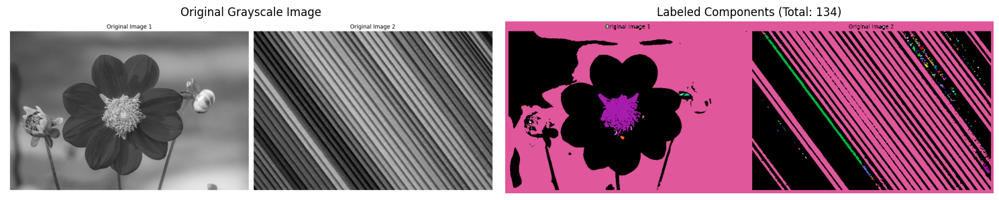

Observations:
 - Each distinct region (component) has now been quantified by features like area and intensity statistics.
 - These numerical features can be used for further analysis, such as filtering components by size or classifying them.


In [11]:
# Manual implementation for simple feature extraction (e.g., statistical properties of regions)

# --- Required utility functions (re-defined for robustness) ---
def global_thresholding(image_grayscale, threshold_value):
    if image_grayscale.ndim != 2:
        print("Error: Input must be a grayscale image for global thresholding.")
        return image_grayscale
    binary_image = (image_grayscale > threshold_value).astype(np.uint8) * 255
    return binary_image

def erode(image_binary, structuring_element):
    if image_binary.ndim != 2 or structuring_element.ndim != 2:
        return image_binary
    img_rows, img_cols = image_binary.shape
    se_rows, se_cols = structuring_element.shape
    output_image = np.zeros_like(image_binary, dtype=np.uint8)
    center_r, center_c = se_rows // 2, se_cols // 2
    for r in range(img_rows):
        for c in range(img_cols):
            all_foreground = True
            for sr in range(se_rows):
                for sc in range(se_cols):
                    if structuring_element[sr, sc] == 1:
                        img_r = r + sr - center_r
                        img_c = c + sc - center_c
                        if not (0 <= img_r < img_rows and 0 <= img_c < img_cols) or \
                           image_binary[img_r, img_c] == 0:
                            all_foreground = False
                            break
                if not all_foreground:
                    break
            if all_foreground:
                output_image[r, c] = 255
    return output_image

def dilate(image_binary, structuring_element):
    if image_binary.ndim != 2 or structuring_element.ndim != 2:
        return image_binary
    img_rows, img_cols = image_binary.shape
    se_rows, se_cols = structuring_element.shape
    output_image = np.zeros_like(image_binary, dtype=np.uint8)
    center_r, center_c = se_rows // 2, se_cols // 2
    for r in range(img_rows):
        for c in range(img_cols):
            any_overlap = False
            for sr in range(se_rows):
                for sc in range(se_cols):
                    if structuring_element[sr, sc] == 1:
                        img_r = r + sr - center_r
                        img_c = c + sc - center_c
                        if (0 <= img_r < img_rows and 0 <= img_c < img_cols) and \
                           image_binary[img_r, img_c] == 255:
                            any_overlap = True
                            break
                if any_overlap:
                    break
            if any_overlap:
                output_image[r, c] = 255
    return output_image

def opening(image_binary, structuring_element):
    eroded_image = erode(image_binary, structuring_element)
    opened_image = dilate(eroded_image, structuring_element)
    return opened_image

def find_connected_components(image_binary, connectivity=4):
    if image_binary.ndim != 2:
        return None, None
    img_rows, img_cols = image_binary.shape
    labeled_image = np.zeros_like(image_binary, dtype=np.int32)
    current_label = 0
    if connectivity == 4:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    elif connectivity == 8:
        neighbors = [
            (-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)
        ]
    else:
        return None, None
    for r in range(img_rows):
        for c in range(img_cols):
            if image_binary[r, c] == 255 and labeled_image[r, c] == 0:
                current_label += 1
                stack = [(r, c)]
                labeled_image[r, c] = current_label
                while stack:
                    current_r, current_c = stack.pop()
                    for dr, dc in neighbors:
                        next_r, next_c = current_r + dr, current_c + dc
                        if (0 <= next_r < img_rows and 0 <= next_c < img_cols) and \
                           image_binary[next_r, next_c] == 255 and labeled_image[next_r, next_c] == 0:
                            labeled_image[next_r, next_c] = current_label
                            stack.append((next_r, next_c))
    return labeled_image, current_label
# -------------------------------------------------------------------

def extract_region_features(labeled_image, original_grayscale_image):
    if labeled_image is None or original_grayscale_image is None:
        print("Error: Labeled image or grayscale image not available for feature extraction.")
        return {}

    if labeled_image.shape != original_grayscale_image.shape:
        print("Error: Labeled image and grayscale image must have the same dimensions.")
        return {}

    features = {}
    num_labels = np.max(labeled_image)

    for label in range(1, num_labels + 1):
        # Create a mask for the current component
        mask = (labeled_image == label)

        # Extract the region from the grayscale image
        region_pixels = original_grayscale_image[mask]

        if region_pixels.size == 0:
            continue # Skip empty regions

        # Calculate basic statistical features
        mean_intensity = np.mean(region_pixels)
        std_intensity = np.std(region_pixels)
        min_intensity = np.min(region_pixels)
        max_intensity = np.max(region_pixels)
        area = np.sum(mask) # Number of pixels in the region

        features[label] = {
            'area': area,
            'mean_intensity': mean_intensity,
            'std_intensity': std_intensity,
            'min_intensity': min_intensity,
            'max_intensity': max_intensity
        }
    return features


# Demonstration of Feature Extraction
if 'gray_image' in locals() and gray_image is not None:
    # First, ensure we have a labeled image from CCA
    # We'll re-run a simplified CCA using global_thresholding and opening for clarity
    base_binary_image = global_thresholding(gray_image, 100)
    structuring_element_3x3 = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.uint8)
    cleaned_binary_image = opening(base_binary_image, structuring_element_3x3)

    # Perform CCA (using 8-connectivity for this example)
    labeled_components, num_components = find_connected_components(cleaned_binary_image, connectivity=8)

    if labeled_components is not None and num_components > 0:
        # Extract features for each labeled component
        extracted_features = extract_region_features(labeled_components, gray_image)

        print(f"Extracted features for {len(extracted_features)} components:")
        # Display features for a few components (or all if few)
        display_count = 0
        for label, feature_data in extracted_features.items():
            print(f"Component {label}: Area={feature_data['area']}, Mean Intensity={feature_data['mean_intensity']:.2f}, Std Dev={feature_data['std_intensity']:.2f}")
            display_count += 1
            if display_count >= 5: # Limit display to first 5 components for brevity
                print("... (and more)")
                break

        # Optional: Visualize a few components with their features highlighted
        if num_components > 0:
            fig, axes = plt.subplots(1, 2, figsize=(15, 7))

            axes[0].imshow(gray_image, cmap='gray')
            axes[0].set_title('Original Grayscale Image')
            axes[0].axis('off')

            # Create an image to visualize labeled components
            # Assign a random color to each component for better visualization
            colored_labeled_image = np.zeros((*labeled_components.shape, 3), dtype=np.uint8)
            unique_labels = np.unique(labeled_components)
            for label in unique_labels:
                if label == 0: # Background
                    continue
                color = np.random.randint(0, 255, 3, dtype=np.uint8)
                colored_labeled_image[labeled_components == label] = color

            axes[1].imshow(colored_labeled_image)
            axes[1].set_title(f'Labeled Components (Total: {num_components})')
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()

            print("Observations:")
            print(" - Each distinct region (component) has now been quantified by features like area and intensity statistics.")
            print(" - These numerical features can be used for further analysis, such as filtering components by size or classifying them.")
    else:
        print("No connected components found for feature extraction demonstration.")
else:
    print("Grayscale image not available for feature extraction demonstration. Please check previous cell outputs.")

## 20. Edge Features: Canny Edge Detection

**Edge detection** is a fundamental task in image processing that aims to identify points in a digital image at which the image brightness changes sharply or, more formally, has discontinuities. These discontinuities typically correspond to the boundaries of objects, texture changes, or surface markings, which are crucial for object recognition, segmentation, and feature extraction.

### The Canny Edge Detector

The **Canny Edge Detector**, developed by John F. Canny in 1986, is a multi-stage algorithm widely recognized as one of the most effective edge detection methods. It aims to satisfy three main criteria:

1.  **Good Detection**: The algorithm should detect as many true edges as possible.
2.  **Good Localization**: Detected edges should be as close as possible to the true edges.
3.  **Minimal Response**: A given edge in the image should only be marked once, and image noise should not create false edges.

### Stages of Canny Edge Detection

The Canny algorithm proceeds through five main steps:

1.  **Noise Reduction (Gaussian Smoothing)**: Edge detection is sensitive to noise. The first step involves smoothing the image with a Gaussian filter to suppress noise while preserving edges as much as possible.

2.  **Gradient Calculation**: The smoothed image is then filtered with a Sobel operator (or similar) in both horizontal (Gx) and vertical (Gy) directions to find the intensity gradients. From these, the gradient magnitude ($G$) and direction ($	heta$) are calculated.
    $$ G = \sqrt{G_x^2 + G_y^2} $$
    $$ \theta = \operatorname{atan2}(G_y, G_x) $$

3.  **Non-Maximum Suppression (NMS)**: This step thins the edges. For each pixel, it checks if its gradient magnitude is a local maximum in the direction of the gradient. If not, the pixel is suppressed (set to zero). This leaves only thin lines (ridges) as potential edges.

4.  **Double Thresholding**: NMS often leaves behind some spurious edge fragments and true edge pixels with varying intensities. To address this, two thresholds are used: a `high_threshold` and a `low_threshold`.
    *   Pixels with gradient magnitude above `high_threshold` are immediately classified as strong edge pixels.
    *   Pixels with gradient magnitude below `low_threshold` are immediately suppressed.
    *   Pixels with gradient magnitude between the `low_threshold` and `high_threshold` are classified as weak edge pixels, and their fate depends on the next step.

5.  **Edge Tracking by Hysteresis**: This final step converts the weak edge pixels into strong ones if and only if they are connected to a strong edge pixel. This process eliminates isolated weak edges (likely noise) and ensures that only true edges are kept.

### Problem Statement for Canny Edge Detection

For our defect detection task, precisely locating object boundaries is paramount. Simple gradient-based methods can be noisy or produce thick edges. Canny's multi-stage approach is designed to produce cleaner, thinner, and more accurately localized edges, which are ideal for subsequent analysis like measuring defect dimensions or shapes.

### Solution for Canny Edge Detection

We will implement a manual Canny Edge Detector using the previously defined `apply_convolution_with_padding` and `sobel_operator` functions. This will involve manually implementing Gaussian smoothing, non-maximum suppression, double thresholding, and edge tracking by hysteresis.

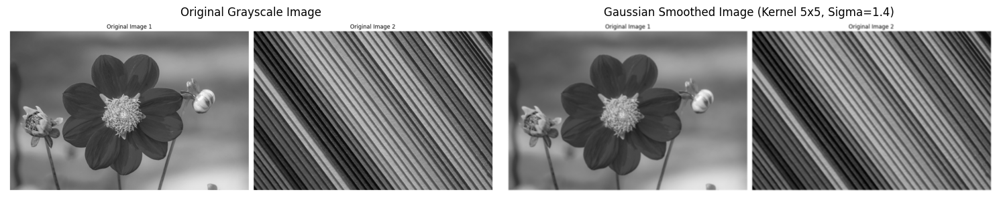

Observations:
 - The Gaussian filter has blurred the image, reducing noise while attempting to preserve important edge information.
 - This smoothing is crucial for preventing noisy pixels from being detected as false edges in later stages.


In [12]:
import math

# Helper function to generate a 2D Gaussian kernel
def gaussian_kernel(size, sigma):
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    sum_val = 0
    for r in range(size):
        for c in range(size):
            x, y = r - center, c - center
            kernel[r, c] = (1 / (2 * math.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
            sum_val += kernel[r, c]
    return kernel / sum_val # Normalize the kernel so sum of elements is 1

# --- Canny Edge Detector Implementation (Step 1: Gaussian Smoothing) ---

if 'gray_image' in locals() and gray_image is not None:
    # Define Gaussian kernel parameters
    kernel_size_gaussian = 5
    sigma = 1.4

    # Generate Gaussian kernel
    gauss_kernel = gaussian_kernel(kernel_size_gaussian, sigma)

    # Apply Gaussian smoothing to the grayscale image
    smoothed_image = apply_convolution_with_padding(gray_image, gauss_kernel)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale Image')
    axes[0].axis('off')

    axes[1].imshow(smoothed_image, cmap='gray')
    axes[1].set_title(f'Gaussian Smoothed Image (Kernel {kernel_size_gaussian}x{kernel_size_gaussian}, Sigma={sigma})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - The Gaussian filter has blurred the image, reducing noise while attempting to preserve important edge information.")
    print(" - This smoothing is crucial for preventing noisy pixels from being detected as false edges in later stages.")
else:
    print("Grayscale image not available for Gaussian smoothing demonstration. Please check previous cell outputs.")

### Canny Edge Detector (Step 2: Non-Maximum Suppression)

After computing the gradient magnitude and direction for the smoothed image, the next step in the Canny algorithm is **Non-Maximum Suppression (NMS)**. The goal of NMS is to thin the detected edges, ensuring that only the local maxima of the gradient magnitude are preserved. This results in sharper, one-pixel-wide edges.

**How it works**:

For each pixel in the gradient magnitude image:
1.  Quantize the gradient direction into one of four main angles (0°, 45°, 90°, 135°).
2.  Compare the current pixel's gradient magnitude with the magnitudes of its two neighbors along the gradient direction.
3.  If the current pixel's magnitude is not greater than both of its neighbors along that direction, it is suppressed (set to 0).

This process effectively eliminates spurious responses to edge detection, leaving only the strongest, most localized edges.

### Solution for Non-Maximum Suppression

We will implement NMS manually. This involves iterating through each pixel, determining its gradient direction, and then comparing its magnitude with the magnitudes of adjacent pixels in that specific direction. Pixels that are not local maxima will be set to zero.

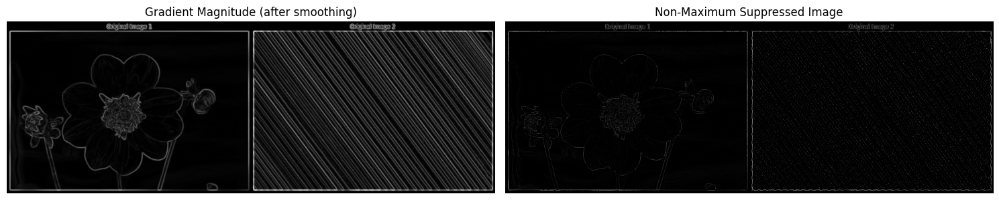

Observations:
 - Non-Maximum Suppression has thinned the edges to single-pixel width.
 - This makes the edge map much cleaner and more precise, reducing redundant edge pixels.


In [13]:
# --- Canny Edge Detector Implementation (Step 2: Non-Maximum Suppression) ---

def non_maximum_suppression(gradient_magnitude, gradient_direction):
    rows, cols = gradient_magnitude.shape
    output_image = np.zeros_like(gradient_magnitude, dtype=np.uint8)

    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            angle = gradient_direction[r, c]
            magnitude = gradient_magnitude[r, c]

            # Quantize angle to 0, 45, 90, 135 degrees
            # 0 degrees: horizontal edge (compare with left/right neighbors)
            # 45 degrees: diagonal edge (compare with top-left/bottom-right neighbors)
            # 90 degrees: vertical edge (compare with top/bottom neighbors)
            # 135 degrees: diagonal edge (compare with top-right/bottom-left neighbors)

            # Angles are 0-360, but directions are symmetric, so 0-180 is sufficient.
            # We'll map to 0, 45, 90, 135 and 180 degrees
            # 0, 180 (horizontal): compare (r, c-1) and (r, c+1)
            # 45 (diagonal): compare (r-1, c+1) and (r+1, c-1)
            # 90 (vertical): compare (r-1, c) and (r+1, c)
            # 135 (diagonal): compare (r-1, c-1) and (r+1, c+1)

            p1 = 0
            p2 = 0

            if (0 <= angle < 22.5) or (157.5 <= angle <= 180) or (337.5 <= angle <= 360) or (180 <= angle < 202.5):
                # Horizontal (0 or 180 degrees)
                p1 = gradient_magnitude[r, c + 1]
                p2 = gradient_magnitude[r, c - 1]
            elif (22.5 <= angle < 67.5) or (202.5 <= angle < 247.5):
                # -45 degrees (top-left to bottom-right)
                p1 = gradient_magnitude[r - 1, c + 1]
                p2 = gradient_magnitude[r + 1, c - 1]
            elif (67.5 <= angle < 112.5) or (247.5 <= angle < 292.5):
                # Vertical (90 degrees)
                p1 = gradient_magnitude[r - 1, c]
                p2 = gradient_magnitude[r + 1, c]
            elif (112.5 <= angle < 157.5) or (292.5 <= angle < 337.5):
                # 45 degrees (top-right to bottom-left)
                p1 = gradient_magnitude[r - 1, c - 1]
                p2 = gradient_magnitude[r + 1, c + 1]

            if magnitude >= p1 and magnitude >= p2:
                output_image[r, c] = magnitude
            else:
                output_image[r, c] = 0
    return output_image


if 'smoothed_image' in locals() and smoothed_image is not None:
    # Recalculate gradients for the smoothed image to get magnitude and direction
    # We need to re-use sobel_operator, which was defined in 783b21d5
    grad_x_smoothed, grad_y_smoothed, grad_magnitude_smoothed, grad_direction_smoothed = sobel_operator(smoothed_image)

    if grad_magnitude_smoothed is not None:
        nms_image = non_maximum_suppression(grad_magnitude_smoothed, grad_direction_smoothed)

        fig, axes = plt.subplots(1, 2, figsize=(15, 7))
        axes[0].imshow(grad_magnitude_smoothed, cmap='gray')
        axes[0].set_title('Gradient Magnitude (after smoothing)')
        axes[0].axis('off')

        axes[1].imshow(nms_image, cmap='gray')
        axes[1].set_title('Non-Maximum Suppressed Image')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        print("Observations:")
        print(" - Non-Maximum Suppression has thinned the edges to single-pixel width.")
        print(" - This makes the edge map much cleaner and more precise, reducing redundant edge pixels.")
    else:
        print("Gradient magnitude not available after smoothing for NMS demonstration.")
else:
    print("Smoothed image not available for NMS demonstration. Please check previous cell outputs.")

### Canny Edge Detector (Step 3: Double Thresholding and Hysteresis)

The final stages of the Canny algorithm involve **Double Thresholding** and **Edge Tracking by Hysteresis**. These steps refine the output of Non-Maximum Suppression to produce a robust set of edges, connecting broken segments and removing false positives.

**Double Thresholding**:

Two thresholds are applied to the non-maximum suppressed gradient magnitude image:
1.  **High Threshold (`high_threshold`)**: Pixels with gradient magnitudes *above* this threshold are classified as **strong edges** (definite edges).
2.  **Low Threshold (`low_threshold`)**: Pixels with gradient magnitudes *below* this threshold are suppressed (set to 0, non-edges).
3.  Pixels with gradient magnitudes *between* the two thresholds are classified as **weak edges**. Their status as true edges depends on their connectivity to strong edges in the next step.

**Edge Tracking by Hysteresis**:

This process converts weak edges into strong edges if they are connected to a strong edge pixel. This step is critical for filling gaps in edges and preventing noisy, isolated edge fragments from being included in the final result.

**How it works**:
1.  Iterate through the image, identifying strong edge pixels.
2.  For each strong edge pixel, examine its neighbors. If any neighbor is a weak edge pixel, that weak edge pixel is then classified as a strong edge and added to the set of pixels to be processed.
3.  This process continues recursively or iteratively until no more weak edge pixels can be connected to strong ones.

### Solution for Double Thresholding and Hysteresis

We will implement these two stages. First, we'll apply the high and low thresholds to categorize pixels as strong, weak, or non-edges. Then, we'll implement an edge tracking algorithm (e.g., using a stack/queue for DFS/BFS) to connect weak edges to strong ones, thus forming the final Canny edge map.

In [19]:
def double_thresholding_and_hysteresis(image_nms, low_threshold, high_threshold):
    rows, cols = image_nms.shape
    # Create an output image of the same size, initialized to non-edges (0)
    output_image = np.zeros_like(image_nms, dtype=np.uint8)

    # Define status for pixels during hysteresis
    # 0: non-edge, 128: weak edge, 255: strong edge
    strong_edge_val = 255
    weak_edge_val = 128

    # Apply double thresholding
    strong_r, strong_c = np.where(image_nms >= high_threshold)
    weak_r, weak_c = np.where((image_nms >= low_threshold) & (image_nms < high_threshold))

    # Mark strong edges in the output image
    output_image[strong_r, strong_c] = strong_edge_val

    # Mark weak edges temporarily (will be processed by hysteresis)
    output_image[weak_r, weak_c] = weak_edge_val

    # Edge Tracking by Hysteresis
    # Use a stack for DFS-like traversal
    stack = []
    for r, c in zip(strong_r, strong_c):
        stack.append((r, c))

    # Define 8-connectivity neighbors for tracking
    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 ( 0, -1),          ( 0, 1),
                 ( 1, -1), ( 1, 0), ( 1, 1)]

    while stack:
        r, c = stack.pop()

        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc

            # Check boundaries and if neighbor is a weak edge
            if (0 <= nr < rows and 0 <= nc < cols) and (output_image[nr, nc] == weak_edge_val):
                output_image[nr, nc] = strong_edge_val # Convert weak to strong
                stack.append((nr, nc)) # Add to stack for further checking

    # Any remaining weak edges that are not connected to strong edges are suppressed
    output_image[output_image == weak_edge_val] = 0

    return output_image

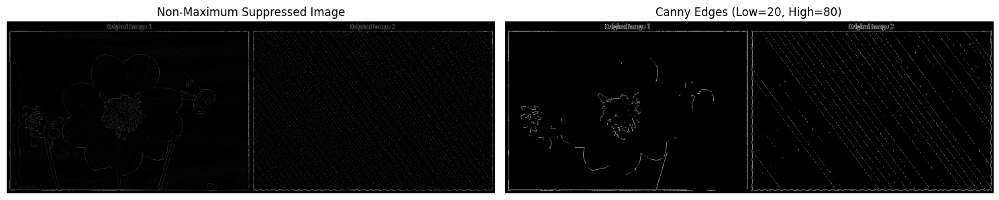

Observations:
 - Double thresholding categorizes pixels into strong, weak, and non-edges.
 - Hysteresis filtering successfully linked weak edges to strong ones, forming continuous contours.
 - The final Canny output provides a clean and precise edge map, ideal for defect detection tasks requiring accurate boundary information.


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming nms_image is available from previous cell execution
# Define thresholds
low_threshold_val = 20 # Original was 50, trying a lower value
high_threshold_val = 80 # Original was 150, trying a lower value

canny_edges = double_thresholding_and_hysteresis(nms_image, low_threshold_val, high_threshold_val)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(nms_image, cmap='gray')
axes[0].set_title('Non-Maximum Suppressed Image')
axes[0].axis('off')

axes[1].imshow(canny_edges, cmap='gray')
axes[1].set_title(f'Canny Edges (Low={low_threshold_val}, High={high_threshold_val})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Observations:")
print(" - Double thresholding categorizes pixels into strong, weak, and non-edges.")
print(" - Hysteresis filtering successfully linked weak edges to strong ones, forming continuous contours.")
print(" - The final Canny output provides a clean and precise edge map, ideal for defect detection tasks requiring accurate boundary information.")


## 21. Edge Features: LoG and DoG Edge Detection

Beyond Canny, other important edge detection techniques include the Laplacian of Gaussian (LoG) and Difference of Gaussians (DoG). These methods are also multi-stage and focus on finding zero-crossings in second-derivative filters, which correspond to edges.

### Laplacian of Gaussian (LoG)

The **Laplacian of Gaussian (LoG)** operator is an edge detection method that combines Gaussian smoothing with the Laplacian operator. Its purpose is to detect sharp changes in intensity (edges) after the image has been smoothed to reduce noise.

**How it works**:
1.  **Gaussian Smoothing**: The image is first smoothed using a Gaussian filter to reduce noise.
2.  **Laplacian Operator**: The Laplacian of the smoothed image is then computed. The Laplacian is a second-order derivative filter that highlights regions of rapid intensity change. Edges are typically found at the **zero-crossings** of the LoG output, where the pixel values change from positive to negative or vice versa.

**Mathematical Representation**: The LoG operator can be expressed as: $$ \text{LoG}(x, y) = -\frac{1}{\pi \sigma^4} \left[ 1 - \frac{x^2+y^2}{2\sigma^2} \right] e^{-\frac{x^2+y^2}{2\sigma^2}} $$

### Difference of Gaussians (DoG)

The **Difference of Gaussians (DoG)** is an approximation of the LoG operator and is often computationally more efficient. It is formed by subtracting one Gaussian-smoothed version of an image from another, where the two Gaussian filters have slightly different standard deviations ($\sigma_1$ and $\sigma_2$).

**How it works**:
1.  Apply two different Gaussian filters to the image, one with a smaller standard deviation (to capture finer details) and one with a larger standard deviation (for more smoothing).
2.  Subtract the more heavily smoothed image from the less smoothed image. The resulting image will highlight regions where intensity changes rapidly, similar to LoG.

**Mathematical Representation**: If $G(x, y, \sigma)$ is a Gaussian filter, then DoG is: $$ \text{DoG}(x, y, \sigma_1, \sigma_2) = G(x, y, \sigma_1) * I(x, y) - G(x, y, \sigma_2) * I(x, y) $$

### Problem Statement for LoG and DoG

While Canny is a strong general-purpose edge detector, LoG and DoG offer alternative approaches that can be particularly useful in specific scenarios. For instance, DoG is widely used in feature detection (e.g., SIFT algorithm) due to its scale-space properties. LoG directly finds blob-like structures as well as edges. For defect detection, these methods can help identify features at different scales or offer a more robust response to certain types of edges.

### Solution for LoG and DoG

We will implement both LoG and DoG operators manually. For LoG, we'll create a 2D Laplacian kernel and apply it after Gaussian smoothing. For DoG, we'll apply two Gaussian filters with different sigmas and subtract the results. We will then identify edges using zero-crossings for LoG and strong responses for DoG.

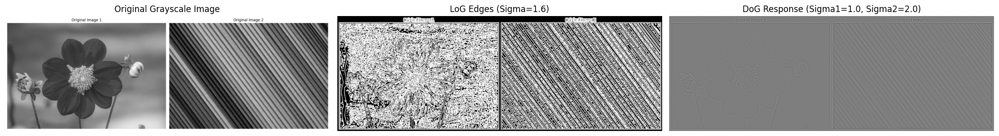

Observations:
 - LoG detects edges by finding zero-crossings after Gaussian smoothing. It's sensitive to scale.
 - DoG approximates LoG and also highlights regions of rapid intensity change. It's often used in multi-scale feature detection.
 - Both operators are second-order derivative filters, making them sensitive to fine details and noise without prior smoothing.


In [15]:
# --- Implementation of Laplacian of Gaussian (LoG) and Difference of Gaussians (DoG) ---

# Helper function to generate a 2D Laplacian kernel
def laplacian_kernel():
    # A common 3x3 Laplacian kernel
    return np.array([[-1, -1, -1],
                     [-1,  8, -1],
                     [-1, -1, -1]], dtype=np.float32)

# Function to find zero-crossings (for LoG)
def find_zero_crossings(image):
    rows, cols = image.shape
    zero_crossings = np.zeros_like(image, dtype=np.uint8)

    # Iterate through image to find zero crossings
    # Check 4-connectivity for sign changes
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            center_val = image[r, c]
            # Check horizontal and vertical neighbors
            if (center_val * image[r, c-1] < 0) or \
               (center_val * image[r, c+1] < 0) or \
               (center_val * image[r-1, c] < 0) or \
               (center_val * image[r+1, c] < 0):
                zero_crossings[r, c] = 255
            # Optionally check diagonal neighbors for 8-connectivity
            elif (center_val * image[r-1, c-1] < 0) or \
                 (center_val * image[r-1, c+1] < 0) or \
                 (center_val * image[r+1, c-1] < 0) or \
                 (center_val * image[r+1, c+1] < 0):
                zero_crossings[r, c] = 255

    return zero_crossings


if 'gray_image' in locals() and gray_image is not None:
    # --- Laplacian of Gaussian (LoG) ---
    # Step 1: Gaussian Smoothing (re-use smoothed_image from Canny or re-calculate)
    # We'll use a new smoothing just for LoG for independent parameter control
    kernel_size_log_gaussian = 5
    sigma_log = 1.6 # Slightly larger sigma can reveal broader features
    gauss_kernel_log = gaussian_kernel(kernel_size_log_gaussian, sigma_log)
    smoothed_image_log = apply_convolution_with_padding(gray_image, gauss_kernel_log)

    # Step 2: Apply Laplacian operator
    lap_kernel = laplacian_kernel()
    laplacian_image = apply_convolution_with_padding(smoothed_image_log, lap_kernel)

    # Step 3: Find zero-crossings
    log_edges = find_zero_crossings(laplacian_image)

    # --- Difference of Gaussians (DoG) ---
    # Apply two Gaussian filters with different sigmas
    sigma1_dog = 1.0
    sigma2_dog = 2.0 # sigma2 is typically sqrt(2) * sigma1 or slightly larger

    gauss_kernel1 = gaussian_kernel(kernel_size_log_gaussian, sigma1_dog)
    gauss_kernel2 = gaussian_kernel(kernel_size_log_gaussian, sigma2_dog)

    smoothed1 = apply_convolution_with_padding(gray_image, gauss_kernel1)
    smoothed2 = apply_convolution_with_padding(gray_image, gauss_kernel2)

    # Subtract the two smoothed images
    dog_image_float = smoothed1.astype(np.float32) - smoothed2.astype(np.float32)
    # Normalize DoG output for display
    dog_image = ((dog_image_float - dog_image_float.min()) / (dog_image_float.max() - dog_image_float.min()) * 255).astype(np.uint8)

    # DoG often detects edges at local extrema, or can be followed by zero-crossing detection
    # For simple visualization, we'll just display the normalized result, which highlights strong responses

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale Image')
    axes[0].axis('off')

    axes[1].imshow(log_edges, cmap='gray')
    axes[1].set_title(f'LoG Edges (Sigma={sigma_log})')
    axes[1].axis('off')

    axes[2].imshow(dog_image, cmap='gray')
    axes[2].set_title(f'DoG Response (Sigma1={sigma1_dog}, Sigma2={sigma2_dog})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - LoG detects edges by finding zero-crossings after Gaussian smoothing. It's sensitive to scale.")
    print(" - DoG approximates LoG and also highlights regions of rapid intensity change. It's often used in multi-scale feature detection.")
    print(" - Both operators are second-order derivative filters, making them sensitive to fine details and noise without prior smoothing.")
else:
    print("Grayscale image not available for LoG and DoG demonstration. Please check previous cell outputs.")

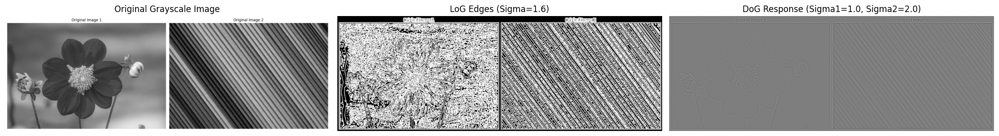

Observations:
 - LoG detects edges by finding zero-crossings after Gaussian smoothing. It's sensitive to scale.
 - DoG approximates LoG and also highlights regions of rapid intensity change. It's often used in multi-scale feature detection.
 - Both operators are second-order derivative filters, making them sensitive to fine details and noise without prior smoothing.


In [16]:
# --- Implementation of Laplacian of Gaussian (LoG) and Difference of Gaussians (DoG) ---

# Helper function to generate a 2D Laplacian kernel
def laplacian_kernel():
    # A common 3x3 Laplacian kernel
    return np.array([[-1, -1, -1],
                     [-1,  8, -1],
                     [-1, -1, -1]], dtype=np.float32)

# Function to find zero-crossings (for LoG)
def find_zero_crossings(image):
    rows, cols = image.shape
    zero_crossings = np.zeros_like(image, dtype=np.uint8)

    # Iterate through image to find zero crossings
    # Check 4-connectivity for sign changes
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            center_val = image[r, c]
            # Check horizontal and vertical neighbors
            if (center_val * image[r, c-1] < 0) or \
               (center_val * image[r, c+1] < 0) or \
               (center_val * image[r-1, c] < 0) or \
               (center_val * image[r+1, c] < 0):
                zero_crossings[r, c] = 255
            # Optionally check diagonal neighbors for 8-connectivity
            elif (center_val * image[r-1, c-1] < 0) or \
                 (center_val * image[r-1, c+1] < 0) or \
                 (center_val * image[r+1, c-1] < 0) or \
                 (center_val * image[r+1, c+1] < 0):
                zero_crossings[r, c] = 255

    return zero_crossings


if 'gray_image' in locals() and gray_image is not None:
    # --- Laplacian of Gaussian (LoG) ---
    # Step 1: Gaussian Smoothing (re-use smoothed_image from Canny or re-calculate)
    # We'll use a new smoothing just for LoG for independent parameter control
    kernel_size_log_gaussian = 5
    sigma_log = 1.6 # Slightly larger sigma can reveal broader features
    gauss_kernel_log = gaussian_kernel(kernel_size_log_gaussian, sigma_log)
    smoothed_image_log = apply_convolution_with_padding(gray_image, gauss_kernel_log)

    # Step 2: Apply Laplacian operator
    lap_kernel = laplacian_kernel()
    laplacian_image = apply_convolution_with_padding(smoothed_image_log, lap_kernel)

    # Step 3: Find zero-crossings
    log_edges = find_zero_crossings(laplacian_image)

    # --- Difference of Gaussians (DoG) ---
    # Apply two Gaussian filters with different sigmas
    sigma1_dog = 1.0
    sigma2_dog = 2.0 # sigma2 is typically sqrt(2) * sigma1 or slightly larger

    gauss_kernel1 = gaussian_kernel(kernel_size_log_gaussian, sigma1_dog)
    gauss_kernel2 = gaussian_kernel(kernel_size_log_gaussian, sigma2_dog)

    smoothed1 = apply_convolution_with_padding(gray_image, gauss_kernel1)
    smoothed2 = apply_convolution_with_padding(gray_image, gauss_kernel2)

    # Subtract the two smoothed images
    dog_image_float = smoothed1.astype(np.float32) - smoothed2.astype(np.float32)
    # Normalize DoG output for display
    dog_image = ((dog_image_float - dog_image_float.min()) / (dog_image_float.max() - dog_image_float.min()) * 255).astype(np.uint8)

    # DoG often detects edges at local extrema, or can be followed by zero-crossing detection
    # For simple visualization, we'll just display the normalized result, which highlights strong responses

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale Image')
    axes[0].axis('off')

    axes[1].imshow(log_edges, cmap='gray')
    axes[1].set_title(f'LoG Edges (Sigma={sigma_log})')
    axes[1].axis('off')

    axes[2].imshow(dog_image, cmap='gray')
    axes[2].set_title(f'DoG Response (Sigma1={sigma1_dog}, Sigma2={sigma2_dog})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - LoG detects edges by finding zero-crossings after Gaussian smoothing. It's sensitive to scale.")
    print(" - DoG approximates LoG and also highlights regions of rapid intensity change. It's often used in multi-scale feature detection.")
    print(" - Both operators are second-order derivative filters, making them sensitive to fine details and noise without prior smoothing.")
else:
    print("Grayscale image not available for LoG and DoG demonstration. Please check previous cell outputs.")

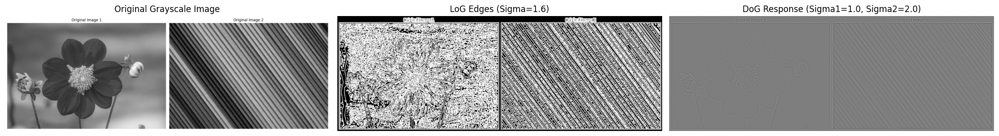

Observations:
 - LoG detects edges by finding zero-crossings after Gaussian smoothing. It's sensitive to scale.
 - DoG approximates LoG and also highlights regions of rapid intensity change. It's often used in multi-scale feature detection.
 - Both operators are second-order derivative filters, making them sensitive to fine details and noise without prior smoothing.


In [17]:
# --- Implementation of Laplacian of Gaussian (LoG) and Difference of Gaussians (DoG) ---

# Helper function to generate a 2D Laplacian kernel
def laplacian_kernel():
    # A common 3x3 Laplacian kernel
    return np.array([[-1, -1, -1],
                     [-1,  8, -1],
                     [-1, -1, -1]], dtype=np.float32)

# Function to find zero-crossings (for LoG)
def find_zero_crossings(image):
    rows, cols = image.shape
    zero_crossings = np.zeros_like(image, dtype=np.uint8)

    # Iterate through image to find zero crossings
    # Check 4-connectivity for sign changes
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            center_val = image[r, c]
            # Check horizontal and vertical neighbors
            if (center_val * image[r, c-1] < 0) or \
               (center_val * image[r, c+1] < 0) or \
               (center_val * image[r-1, c] < 0) or \
               (center_val * image[r+1, c] < 0):
                zero_crossings[r, c] = 255
            # Optionally check diagonal neighbors for 8-connectivity
            elif (center_val * image[r-1, c-1] < 0) or \
                 (center_val * image[r-1, c+1] < 0) or \
                 (center_val * image[r+1, c-1] < 0) or \
                 (center_val * image[r+1, c+1] < 0):
                zero_crossings[r, c] = 255

    return zero_crossings


if 'gray_image' in locals() and gray_image is not None:
    # --- Laplacian of Gaussian (LoG) ---
    # Step 1: Gaussian Smoothing (re-use smoothed_image from Canny or re-calculate)
    # We'll use a new smoothing just for LoG for independent parameter control
    kernel_size_log_gaussian = 5
    sigma_log = 1.6 # Slightly larger sigma can reveal broader features
    gauss_kernel_log = gaussian_kernel(kernel_size_log_gaussian, sigma_log)
    smoothed_image_log = apply_convolution_with_padding(gray_image, gauss_kernel_log)

    # Step 2: Apply Laplacian operator
    lap_kernel = laplacian_kernel()
    laplacian_image = apply_convolution_with_padding(smoothed_image_log, lap_kernel)

    # Step 3: Find zero-crossings
    log_edges = find_zero_crossings(laplacian_image)

    # --- Difference of Gaussians (DoG) ---
    # Apply two Gaussian filters with different sigmas
    sigma1_dog = 1.0
    sigma2_dog = 2.0 # sigma2 is typically sqrt(2) * sigma1 or slightly larger

    gauss_kernel1 = gaussian_kernel(kernel_size_log_gaussian, sigma1_dog)
    gauss_kernel2 = gaussian_kernel(kernel_size_log_gaussian, sigma2_dog)

    smoothed1 = apply_convolution_with_padding(gray_image, gauss_kernel1)
    smoothed2 = apply_convolution_with_padding(gray_image, gauss_kernel2)

    # Subtract the two smoothed images
    dog_image_float = smoothed1.astype(np.float32) - smoothed2.astype(np.float32)
    # Normalize DoG output for display
    dog_image = ((dog_image_float - dog_image_float.min()) / (dog_image_float.max() - dog_image_float.min()) * 255).astype(np.uint8)

    # DoG often detects edges at local extrema, or can be followed by zero-crossing detection
    # For simple visualization, we'll just display the normalized result, which highlights strong responses

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale Image')
    axes[0].axis('off')

    axes[1].imshow(log_edges, cmap='gray')
    axes[1].set_title(f'LoG Edges (Sigma={sigma_log})')
    axes[1].axis('off')

    axes[2].imshow(dog_image, cmap='gray')
    axes[2].set_title(f'DoG Response (Sigma1={sigma1_dog}, Sigma2={sigma2_dog})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(" - LoG detects edges by finding zero-crossings after Gaussian smoothing. It's sensitive to scale.")
    print(" - DoG approximates LoG and also highlights regions of rapid intensity change. It's often used in multi-scale feature detection.")
    print(" - Both operators are second-order derivative filters, making them sensitive to fine details and noise without prior smoothing.")
else:
    print("Grayscale image not available for LoG and DoG demonstration. Please check previous cell outputs.")